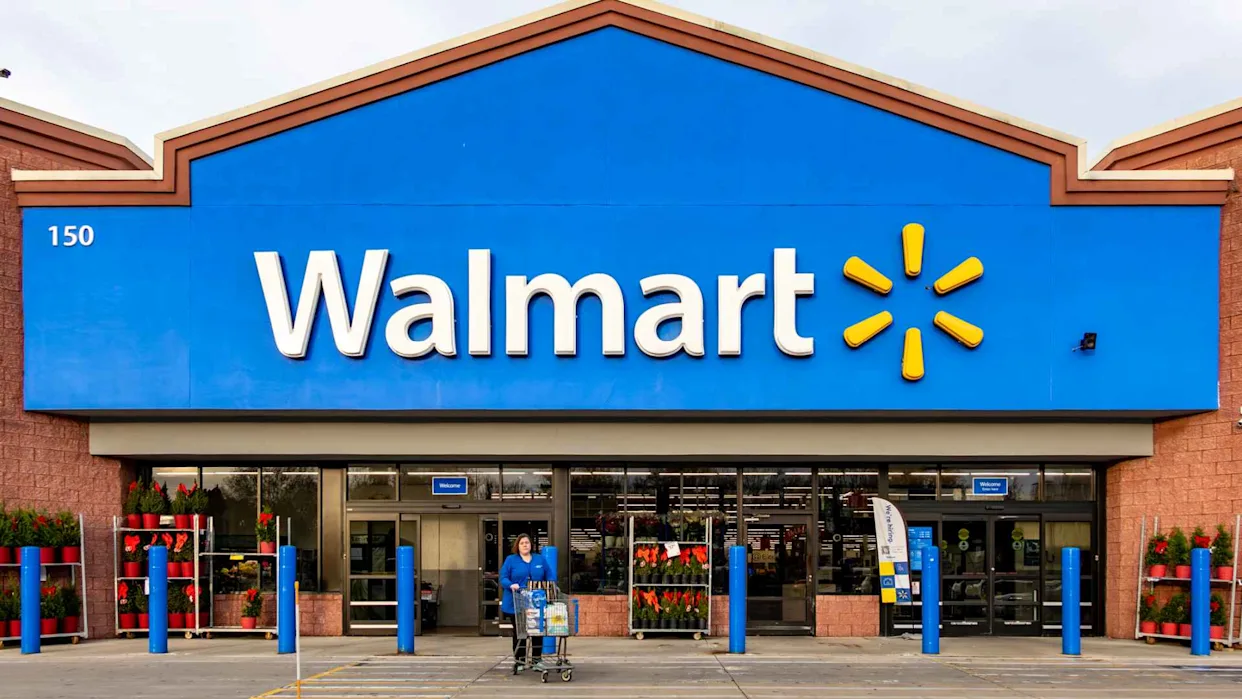

#**About Walmart**

Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.



#**Business Problem**

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female)

#**About Dataset**

The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday. The dataset has the following features:
Dataset link: Walmart_data.csv

* User_ID:	User ID
* Product_ID:	Product ID
* Gender:	Sex of User
* Age:	Age in bins
* Occupation:	Occupation(Masked)
* City_Category:	Category of the City (A,B,C)
* StayInCurrentCityYears:	Number of years stay in current city
* Marital_Status:	Marital Status
* ProductCategory:	Product Category (Masked)
* Purchase:	Purchase Amount

In [ ]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# importing data

df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
# checking shape of df
df.shape

(550068, 10)

In [ ]:
# checking df info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


* The dataset contain's 550068 rows and 10 columns without any missing values

In [ ]:
# finding no of unique values inside each column

df.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [ ]:
for i in df.columns:
  print(i)
  print(df[f'{i}'].unique())
  print()

User_ID
[1000001 1000002 1000003 ... 1004113 1005391 1001529]

Product_ID
['P00069042' 'P00248942' 'P00087842' ... 'P00370293' 'P00371644'
 'P00370853']

Gender
['F' 'M']

Age
['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']

Occupation
[10 16 15  7 20  9  1 12 17  0  3  4 11  8 19  2 18  5 14 13  6]

City_Category
['A' 'C' 'B']

Stay_In_Current_City_Years
['2' '4+' '3' '1' '0']

Marital_Status
[0 1]

Product_Category
[ 3  1 12  8  5  4  2  6 14 11 13 15  7 16 18 10 17  9 20 19]

Purchase
[ 8370 15200  1422 ...   135   123   613]



* The dataset contains 550068 rows and 10 columns with no missing values.
* There are 5891 distinct users and 3631 distinct products.
* The `Gender` column has 2 unique values ('F', 'M').
* The `Age` column has 7 unique age bins.
* There are 21 unique `Occupation` categories and 3 unique `City_Category` (A, B, C).
* `Stay_In_Current_City_Years` has 5 unique values, and `Marital_Status` has 2 unique values.
* There are 20 unique `Product_Category` values.
* The `Purchase` column has 18105 unique purchase amounts.

# **Exploratory Data analysis**

# Univariate Analysis

**Numerical Data**

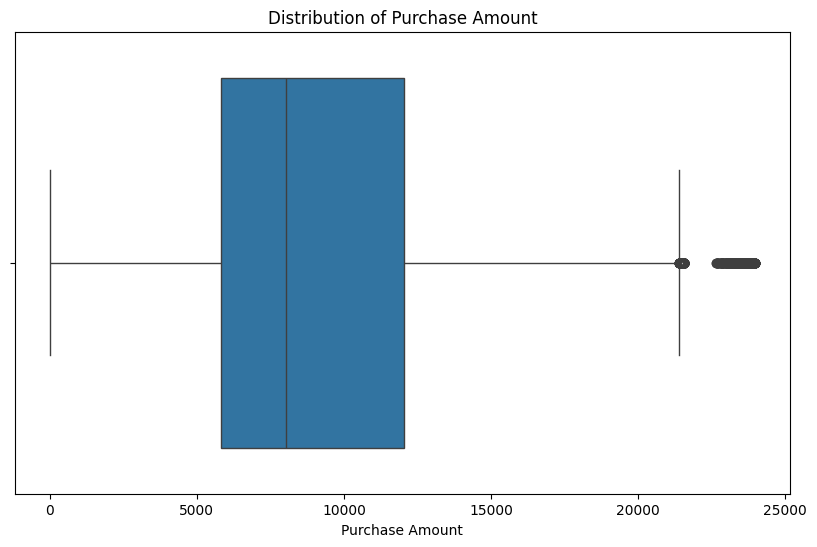

In [ ]:
# purchase amount distribution

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Purchase'])
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.show()

*   The median purchase amount is around 8000-9000.
*   The interquartile range (IQR) shows that the majority of purchases fall between approximately 6000 and 12000.
*   There are a significant number of outliers on the higher side, indicating some customers make very large purchases.
*   The distribution appears to be right-skewed, with the upper whisker extending further than the lower one and more outliers on the higher end.

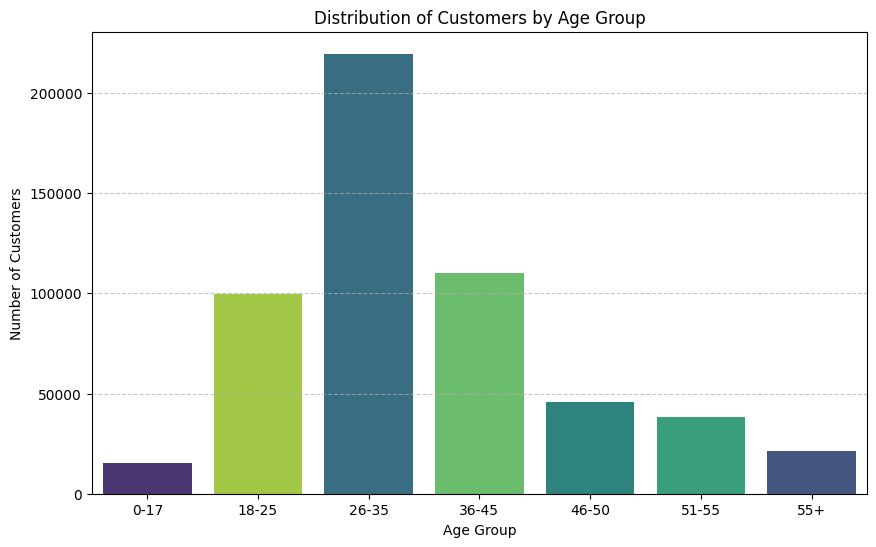

In [ ]:
# age

age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

plt.figure(figsize=(10, 6))
sns.countplot(x='Age', data=df, order=age_order, palette='viridis', hue='Age', legend=False)
plt.title('Distribution of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

*   The largest age group among customers is '26-35', followed by '36-45' and '18-25'. This suggests that young to middle-aged adults are the primary customer base.
*   The '55+' age group has a significant number of customers, indicating that older demographics also contribute substantially to purchases.
*   The '0-17' age group has the fewest customers, which is expected as this group likely has less purchasing power or fewer independent shopping habits.

**Categorical data**

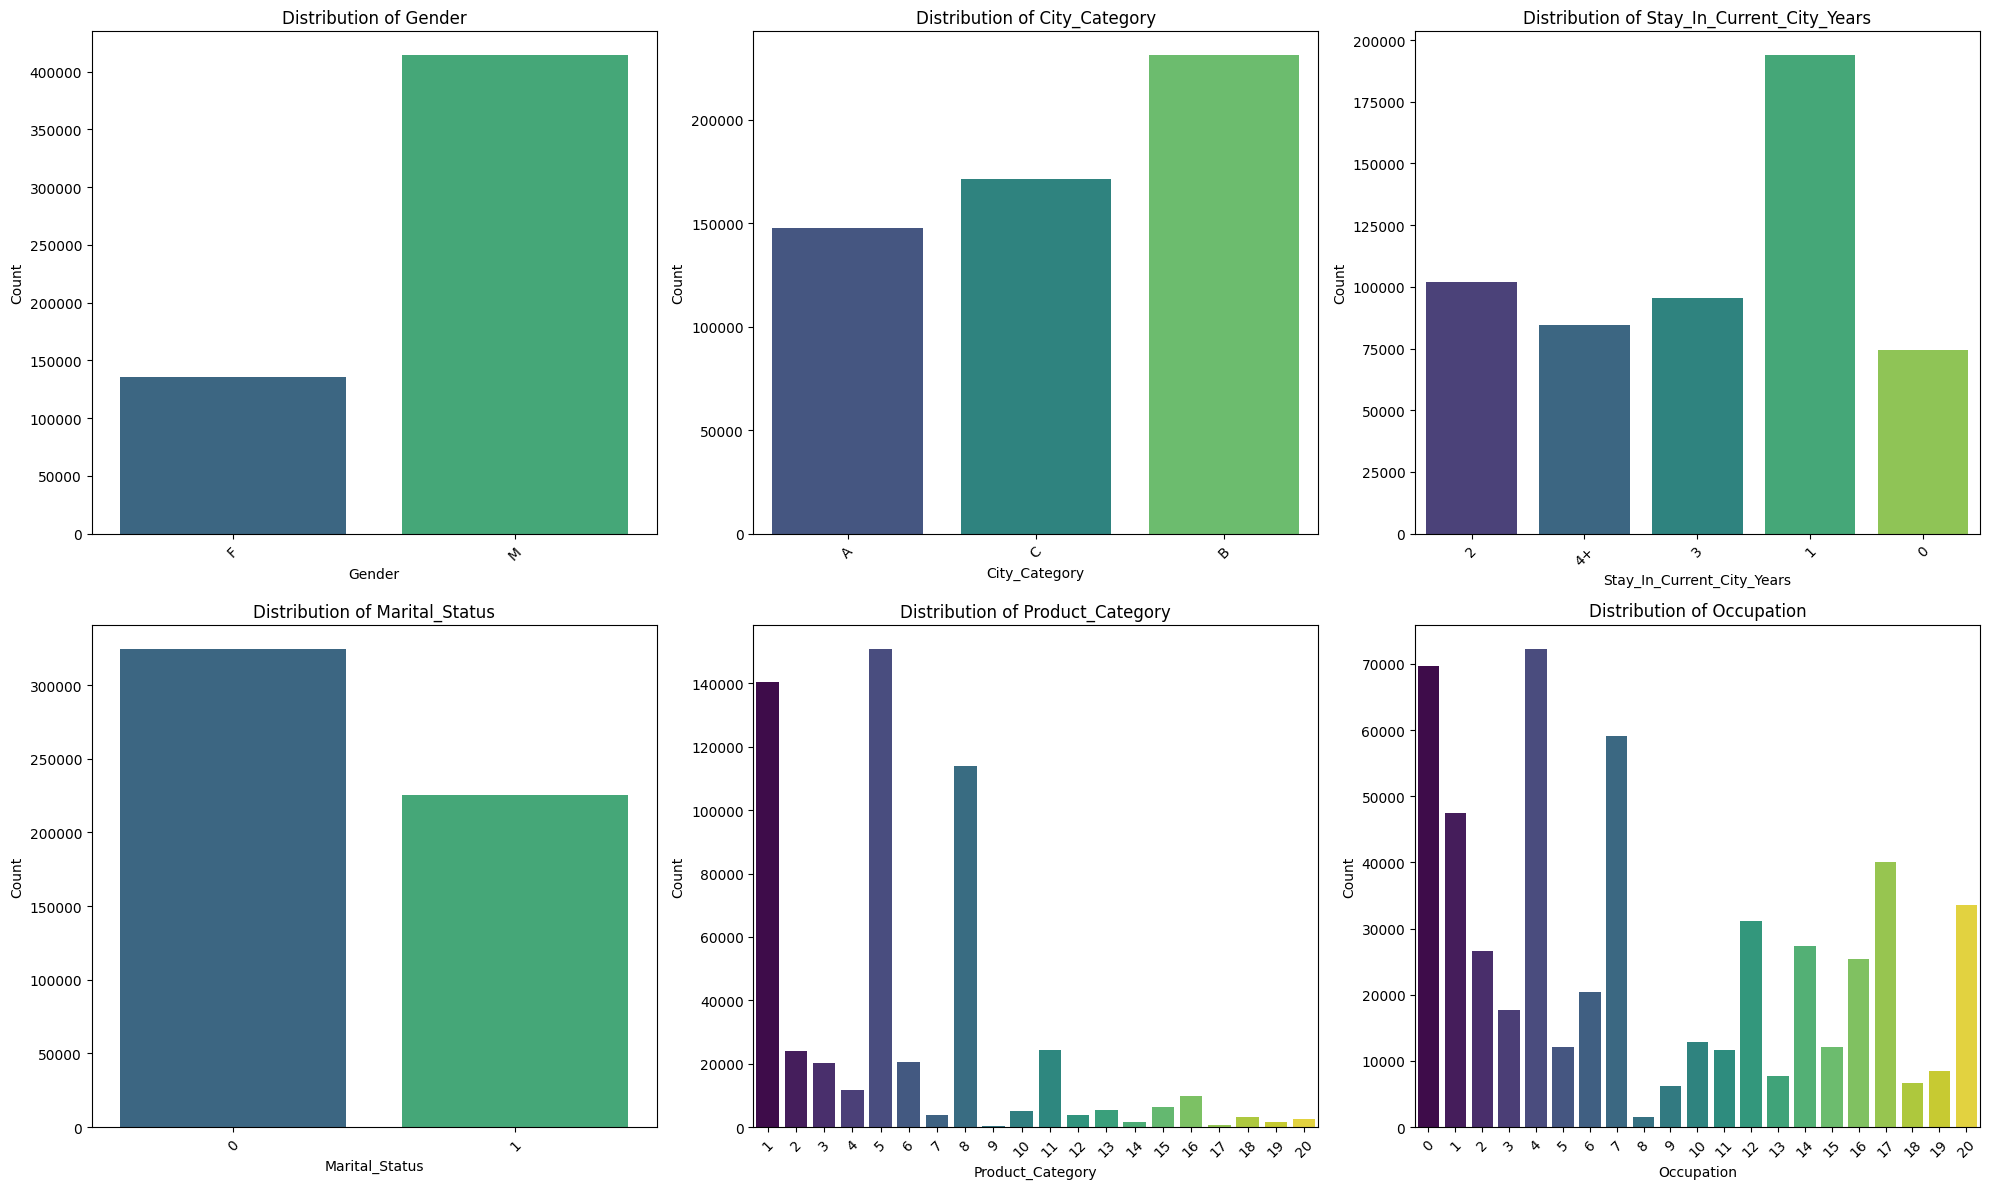

In [ ]:
cate = ['Gender', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category', 'Occupation']


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cate):
    sns.countplot(x=col, data=df, palette='viridis', ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

*   **Gender:** There are significantly more male customers than female customers in the dataset.
*   **City_Category:** City B has the highest number of customers, followed by City C and then City A.
*   **Stay_In_Current_City_Years:** The majority of customers have stayed in their current city for 1 year, followed by 2 years and 3 years. A substantial number have stayed for '4+' years.
*   **Marital_Status:** A larger proportion of customers are unmarried (Marital Status 0) compared to married (Marital Status 1).
*   **Product_Category:** Product categories 1, 5, and 8 appear to be the most frequently purchased, indicating high demand in these categories. Other categories like 10, 14, 15, 16, 17, 18, 19, and 20 have relatively lower counts.
*   **Occupation:** There's a varied distribution across occupations, with some occupations (e.g., 0, 4, 7) having a higher number of customers compared to others. The distribution indicates a diverse customer base across different professional backgrounds.

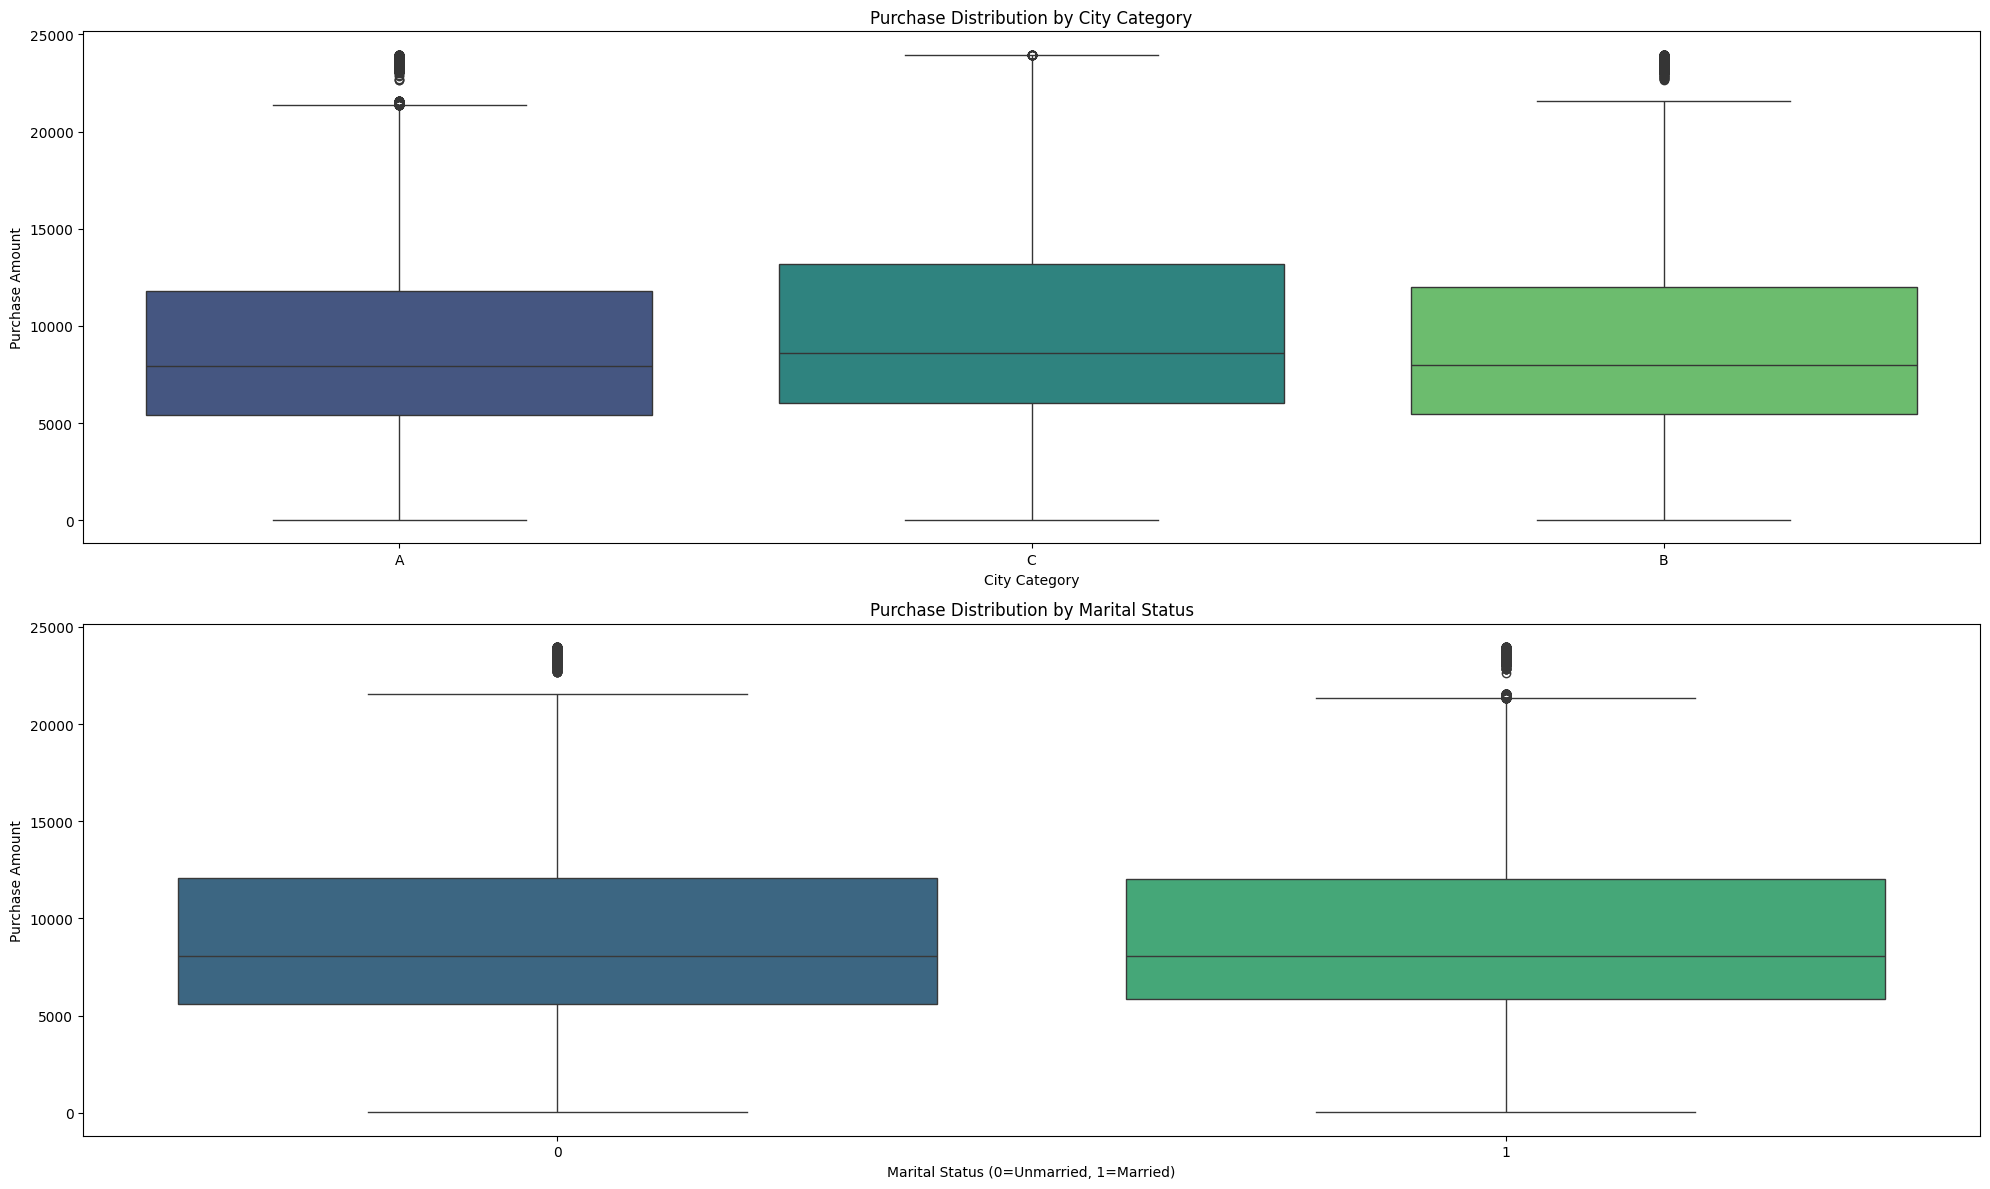

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 12))

# Boxplot for Purchase vs. City_Category
sns.boxplot(x='City_Category', y='Purchase', data=df, palette='viridis', ax=axes[0], hue='City_Category', legend=False)
axes[0].set_title('Purchase Distribution by City Category')
axes[0].set_xlabel('City Category')
axes[0].set_ylabel('Purchase Amount')

# Boxplot for Purchase vs. Marital_Status
sns.boxplot(x='Marital_Status', y='Purchase', data=df, palette='viridis', ax=axes[1], hue='Marital_Status', legend=False)
axes[1].set_title('Purchase Distribution by Marital Status')
axes[1].set_xlabel('Marital Status (0=Unmarried, 1=Married)')
axes[1].set_ylabel('Purchase Amount')

plt.tight_layout()
plt.show()

*   **City Category:** There isn't a significant difference in the median purchase amount across different city categories. City B might show a marginally higher median, but the overall distribution and spread of purchases are quite similar for cities A, B, and C. High-value purchases occur in all city types.

*   **Marital Status:** Marital status (0=Unmarried, 1=Married) does not appear to be a strong factor influencing individual purchase amounts. Both married and unmarried customers exhibit very similar median purchase values and distributions, including the presence of high-value outliers.

#Bi-Variate analysis


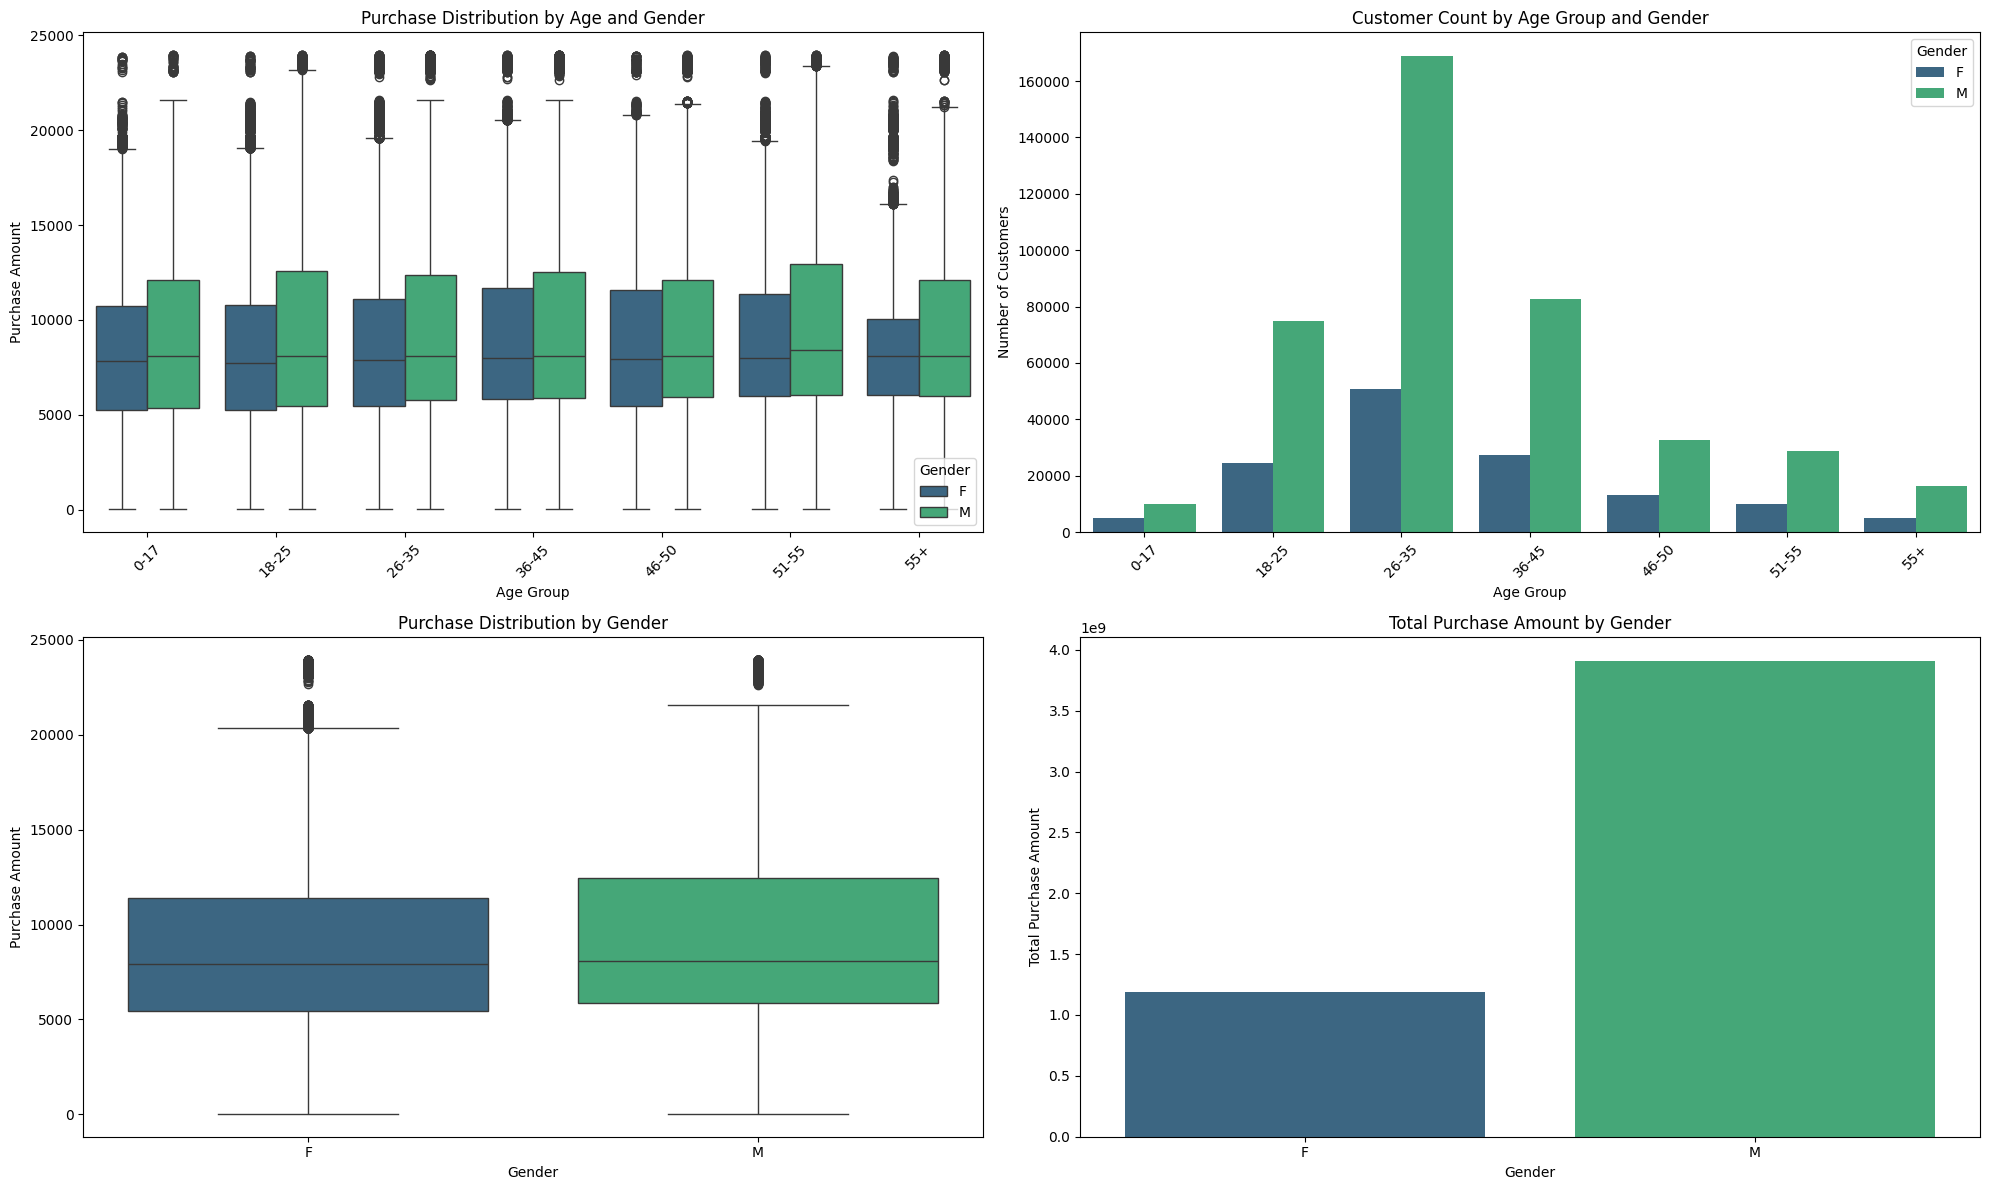

In [ ]:
# Age and purchses by Gender

age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

# Create a figure and a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))

# Subplot 1 (Top-Left): Boxplot - Purchase vs. Age (split by Gender)
sns.boxplot(x='Age', y='Purchase', hue='Gender', data=df, order=age_order, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Purchase Distribution by Age and Gender')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Purchase Amount')
axes[0, 0].tick_params(axis='x', rotation=45)

# Subplot 2 (Top-Right): Countplot - Age distribution by Gender
sns.countplot(x='Age', hue='Gender', data=df, order=age_order, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Customer Count by Age Group and Gender')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].tick_params(axis='x', rotation=45)

# Subplot 3 (Bottom-Left): Boxplot - Purchase vs. Gender
sns.boxplot(x='Gender', y='Purchase', hue='Gender', data=df, palette='viridis', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Purchase Distribution by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Purchase Amount')

# Subplot 4 (Bottom-Right): Barplot - Total Purchase by Gender
gender_purchase_sum = df.groupby('Gender')['Purchase'].sum().reset_index()
sns.barplot(x='Gender', y='Purchase', hue='Gender', data=gender_purchase_sum, palette='viridis', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Total Purchase Amount by Gender')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Total Purchase Amount')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

*   **Customer Demographics (Age & Gender):** Male customers are significantly more numerous across almost all age groups compared to female customers. The '26-35' age group shows the highest customer count for both genders, followed by '36-45' and '18-25'.

*   **Purchase Amount Distribution by Gender:** While the median purchase amount appears similar for both genders, the box plots suggest that male customers tend to have a slightly wider spread of purchase amounts, especially in the upper quartiles, with potentially higher maximum purchases.

*   **Purchase Amount Distribution by Age and Gender:**
    *   For most age groups, the median purchase amount is comparable between males and females.
    *   There isn't a clear trend indicating that one gender consistently purchases higher value items across all age groups, but individual variability exists.

*   **Total Purchase Amount:** Despite fewer female customers, the total purchase amount by males is substantially higher than that by females. This could be due to the sheer volume of male customers or a combination of higher individual purchase values and greater frequency of purchases from male customers.

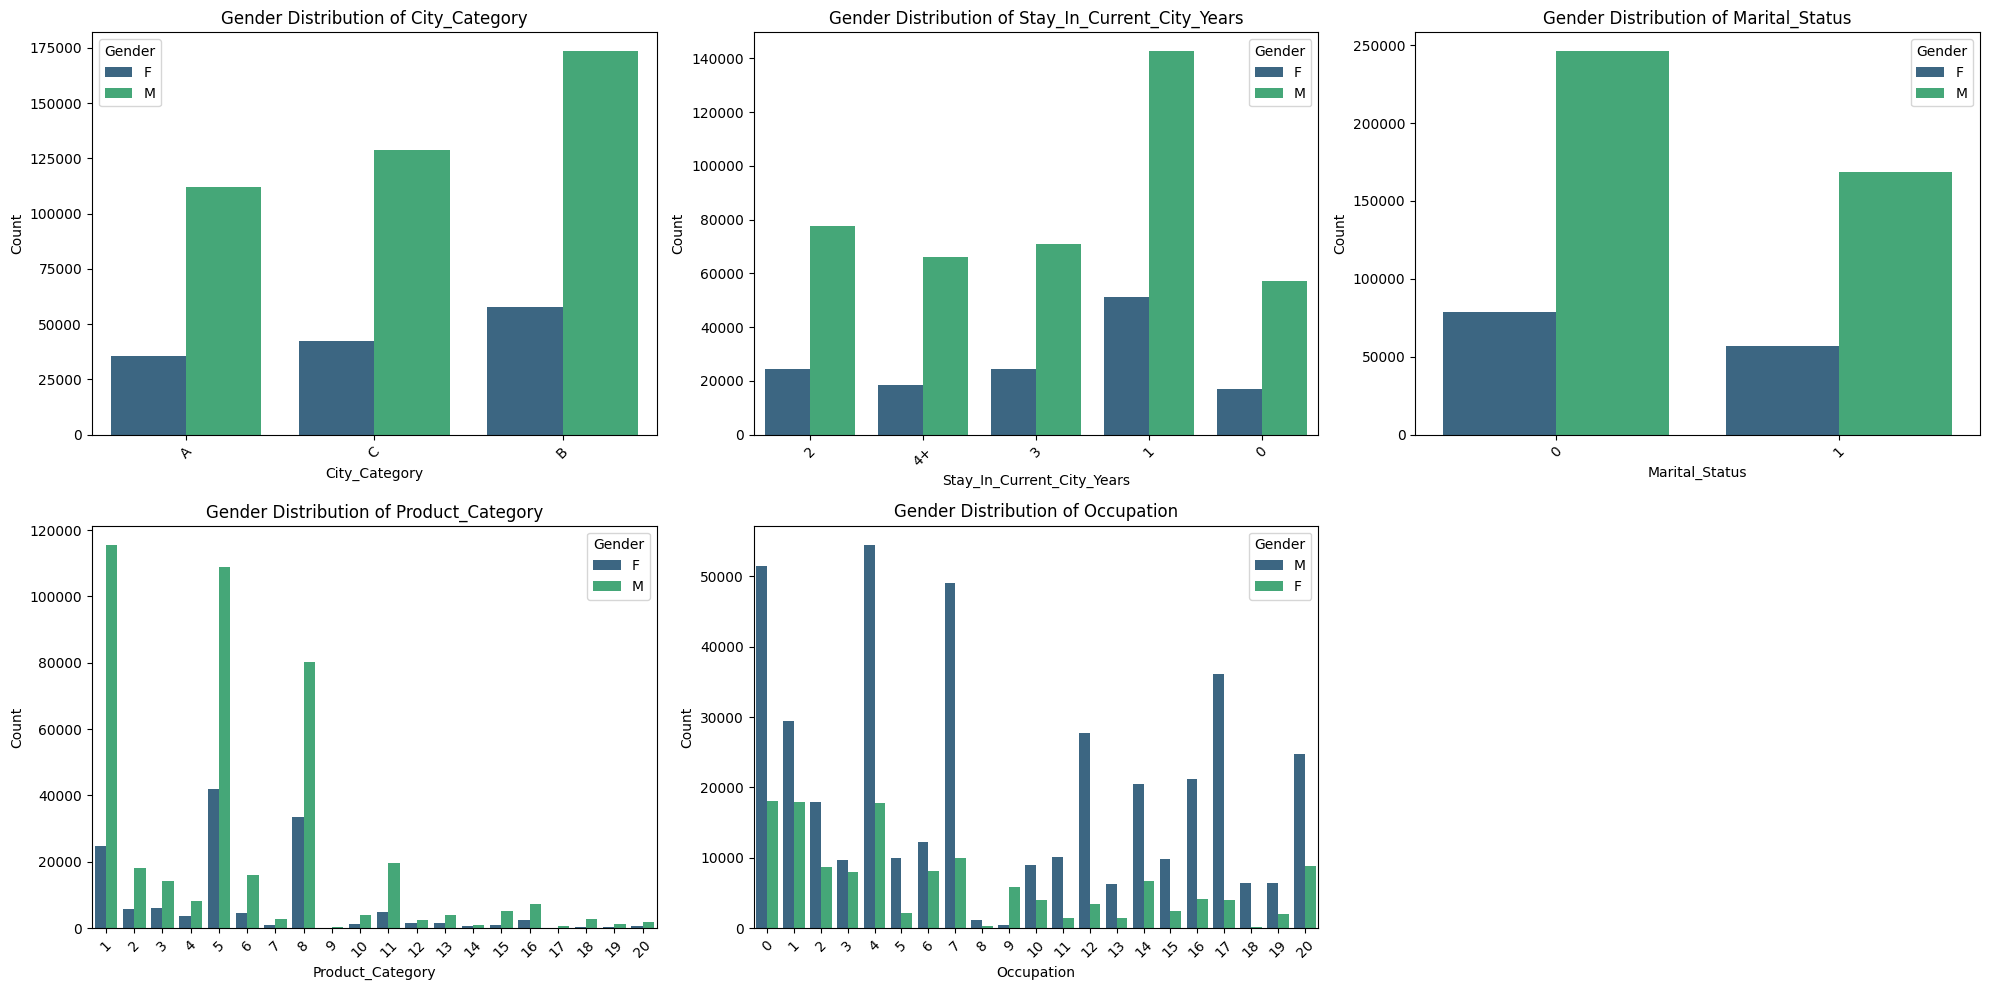

In [ ]:
#Gender wise distribution accross other columns

cate = ['City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category', 'Occupation']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cate):
  sns.countplot(x=col, data=df, hue='Gender', palette='viridis', ax=axes[i])
  axes[i].set_title(f'Gender Distribution of {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')
  axes[i].tick_params(axis='x', rotation=45)

# Turn off any unused subplots
for j in range(len(cate), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

This analysis shows how gender distribution varies across different categorical features:

*   **City Category:** In all three city categories (A, B, C), there is a consistent trend of significantly more male customers than female customers. City B has the highest overall customer count, and this holds true for both genders, with males being dominant.

*   **Stay In Current City Years:** For every duration of stay (0, 1, 2, 3, 4+ years), the number of male customers consistently outweighs the number of female customers. The '1 year' category shows the highest customer count for both genders, again with a clear male majority.

*   **Marital Status:** Both unmarried (0) and married (1) customer groups show a higher proportion of males compared to females. The unmarried group has a larger overall customer base, and within that, males are more prevalent.

*   **Product Category:** Across almost all product categories, male customers outnumber female customers. Some categories like 1, 5, and 8, which are generally popular, show a substantial lead in male purchasers. There might be some categories where the difference is less pronounced or where females have a slightly higher, though not dominant, presence, but the overall pattern is male majority.

*   **Occupation:** Similarly, across the diverse range of occupations, male customers are more numerous than female customers in almost every category. Occupations with higher overall customer counts (e.g., 0, 4, 7) reflect this male majority even more clearly.

**Overall Insight:** The consistent theme across all these categorical features is that the dataset contains a significantly higher number of male customers compared to female customers, aligning with the initial gender distribution observed in the dataset. This majority of the customers are impacts the distribution within every sub-category analyzed.

# Multi Variate analysis

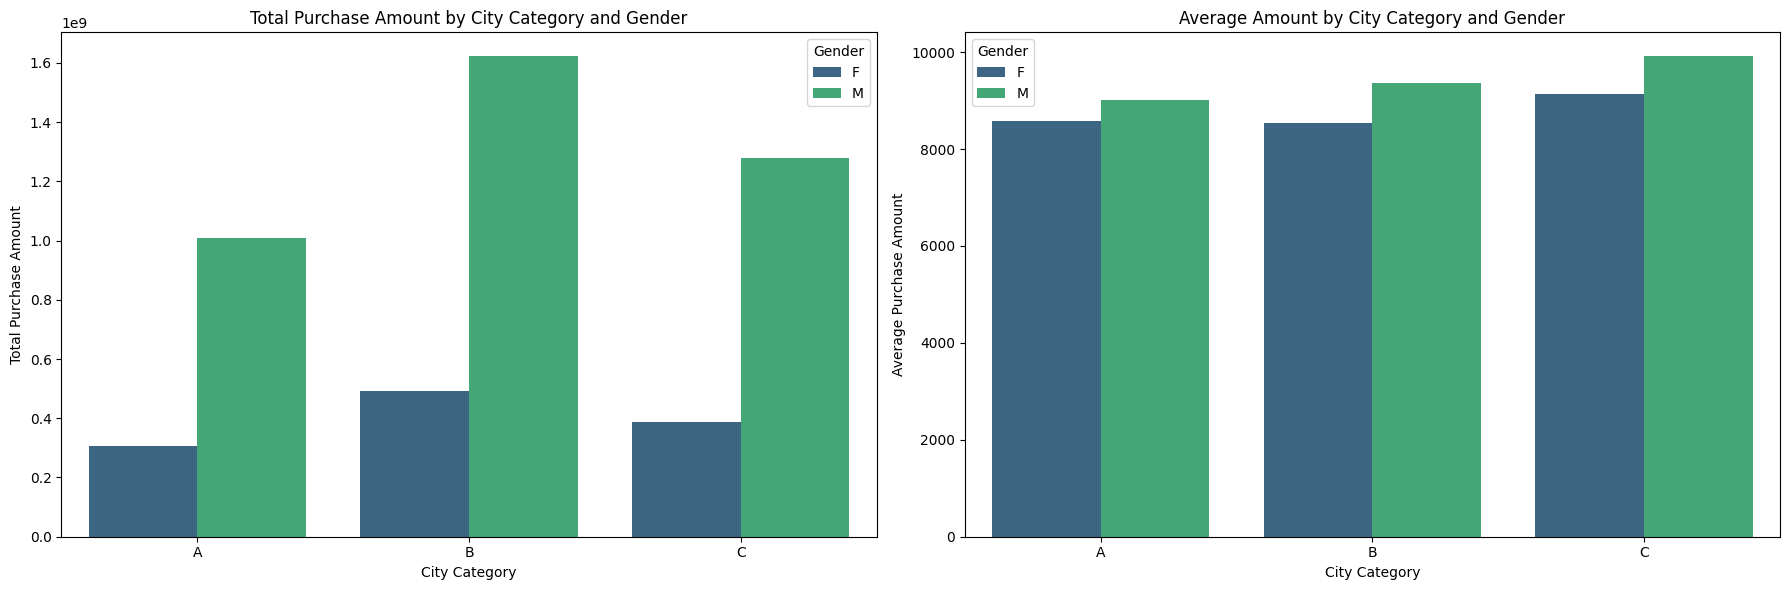

In [ ]:
# checking if there is any difference in purchase pattern in city level for male and female customers by purchase amount

purch_city = df.groupby(['City_Category', 'Gender'])['Purchase'].sum().reset_index()

# Calculate average purchase by gender
avg_purchase_gender = df.groupby(['City_Category','Gender'])['Purchase'].mean().reset_index()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Subplot 1: Total Purchase Amount by City Category and Gender
sns.barplot(x='City_Category', y='Purchase', hue='Gender', data=purch_city, ax=axes[0], palette='viridis')
axes[0].set_title('Total Purchase Amount by City Category and Gender')
axes[0].set_xlabel('City Category')
axes[0].set_ylabel('Total Purchase Amount')
axes[0].legend(title='Gender')

# Subplot 2: Average Purchase Amount by City Category and Gender
sns.barplot(x='City_Category', y='Purchase', hue='Gender', data= avg_purchase_gender, ax=axes[1], palette='viridis')
axes[1].set_title('Average Amount by City Category and Gender')
axes[1].set_xlabel('City Category')
axes[1].set_ylabel('Average Purchase Amount')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

### Findings from 'Total Purchase Amount by City Category and Gender':
*   **Majority of the customers are in Total Purchases:** Similar to previous observations, male customers contribute a significantly higher total purchase amount across all city categories (A, B, and C) compared to female customers. This reaffirms the overall higher representation and spending power of males in the dataset.
*   **City B Leads in Total Volume:** City B consistently shows the highest total purchase amount for both genders, suggesting it's the most commercially active city in terms of sheer purchase volume.

### Findings from 'Average Purchase Amount by City Category and Gender':
*   **Males Have Higher Average Purchases:** In every city category, male customers exhibit a higher average purchase amount per transaction than female customers. This indicates that, on average, individual male purchases are more expensive than individual female purchases.
*   **City C has Highest Average Purchases:** Customers in City C (both male and female) tend to have the highest average purchase amounts, suggesting that this city might attract customers who buy higher-value items or make more substantial individual purchases, despite not having the highest *total* purchase volume.
*   **City A and B in Average:** City A and B show slightly lower average purchase amounts compared to City C, with City B having the lowest average for females and City A the lowest average for males.
*   **Closer Average Purchase:** While male total purchase amounts are significantly higher than female, the average purchase amount of female customers is closer to male customers in all cities.

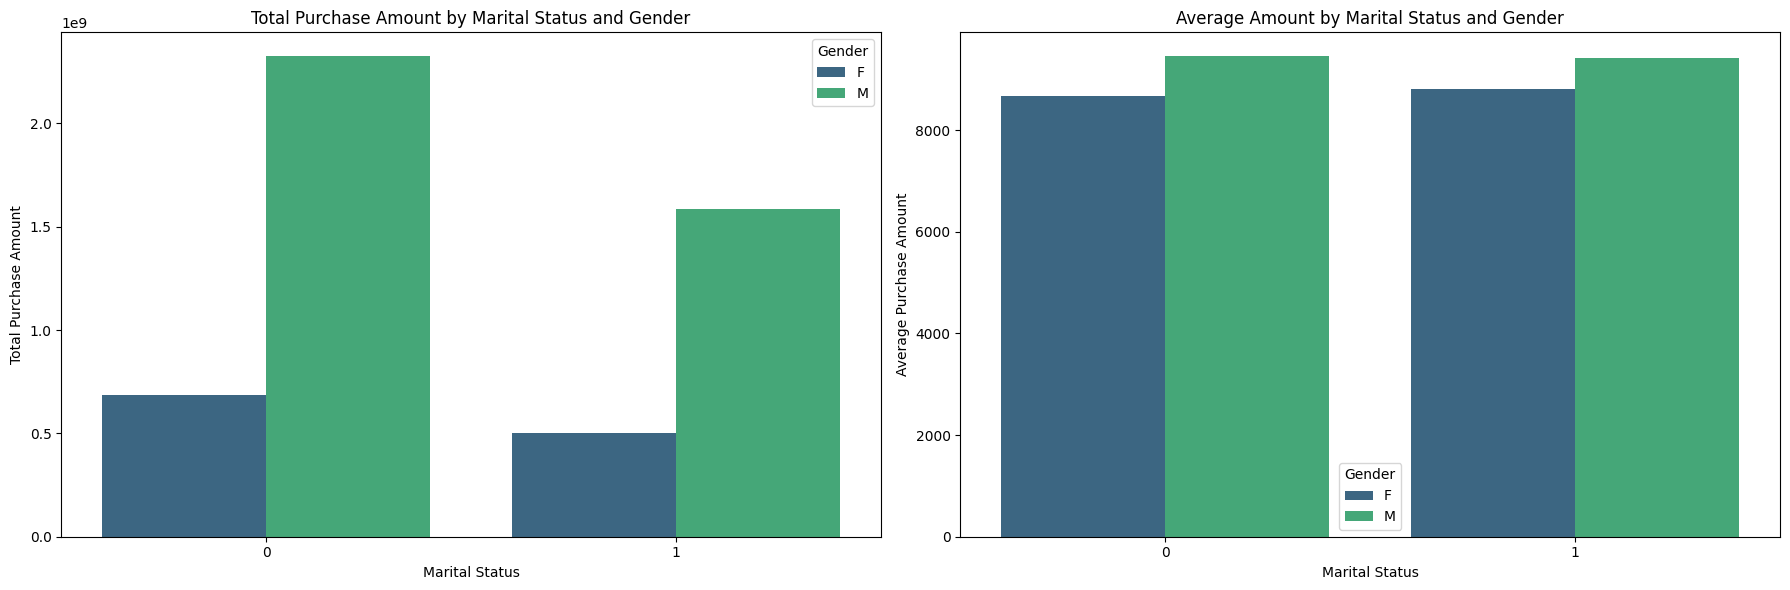

In [ ]:
# checking if there are any differnce in purchase pattern for maried and un maried male and female customers by purchase amount

purch_city = df.groupby(['Marital_Status', 'Gender'])['Purchase'].sum().reset_index()

avg_purchase_gender = df.groupby(['Marital_Status','Gender'])['Purchase'].mean().reset_index()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,6))

sns.barplot(x='Marital_Status', y='Purchase', hue='Gender', data=purch_city, ax=axes[0], palette='viridis')
axes[0].set_title('Total Purchase Amount by Marital Status and Gender')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Total Purchase Amount')
axes[0].legend(title='Gender')

sns.barplot(x='Marital_Status', y='Purchase', hue='Gender', data=avg_purchase_gender, ax=axes[1], palette='viridis')
axes[1].set_title('Average Amount by Marital Status and Gender')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Average Purchase Amount')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()



### Findings from 'Total Purchase Amount by Marital Status and Gender':
*   **Majority of the customers are Across Marital Statuses:** In both the unmarried (0) and married (1) categories, male customers contribute significantly more to the total purchase amount than female customers. This again highlights the higher volume or spending power of male customers.
*   **Unmarried Customers Lead in Total Purchases:** The total purchase amount from unmarried customers (both male and female combined) is higher than that from married customers. Unmarried males, in particular, show the highest total purchase volume.

### Findings from 'Average Amount by Marital Status and Gender':
*   **Males Have Higher Average Purchases:** Similar to previous analyses, male customers show a consistently higher *average* purchase amount per transaction compared to female customers, regardless of their marital status.
*   **Marital Status Impact on Average Purchase:** The difference in average purchase amount between married and unmarried customers for a given gender is quite small. For females, married individuals have a slightly higher average purchase, while for males, unmarried individuals have a slightly higher average purchase.
*   **Gender Gap in Average Purchases:** While males have higher average purchases, the difference in average purchase amount between genders is not as dramatic as the difference in *total* purchase amount. This suggests that the large disparity in total purchases is more driven by the sheer number of male customers and their overall activity rather than a massive difference in individual transaction value.

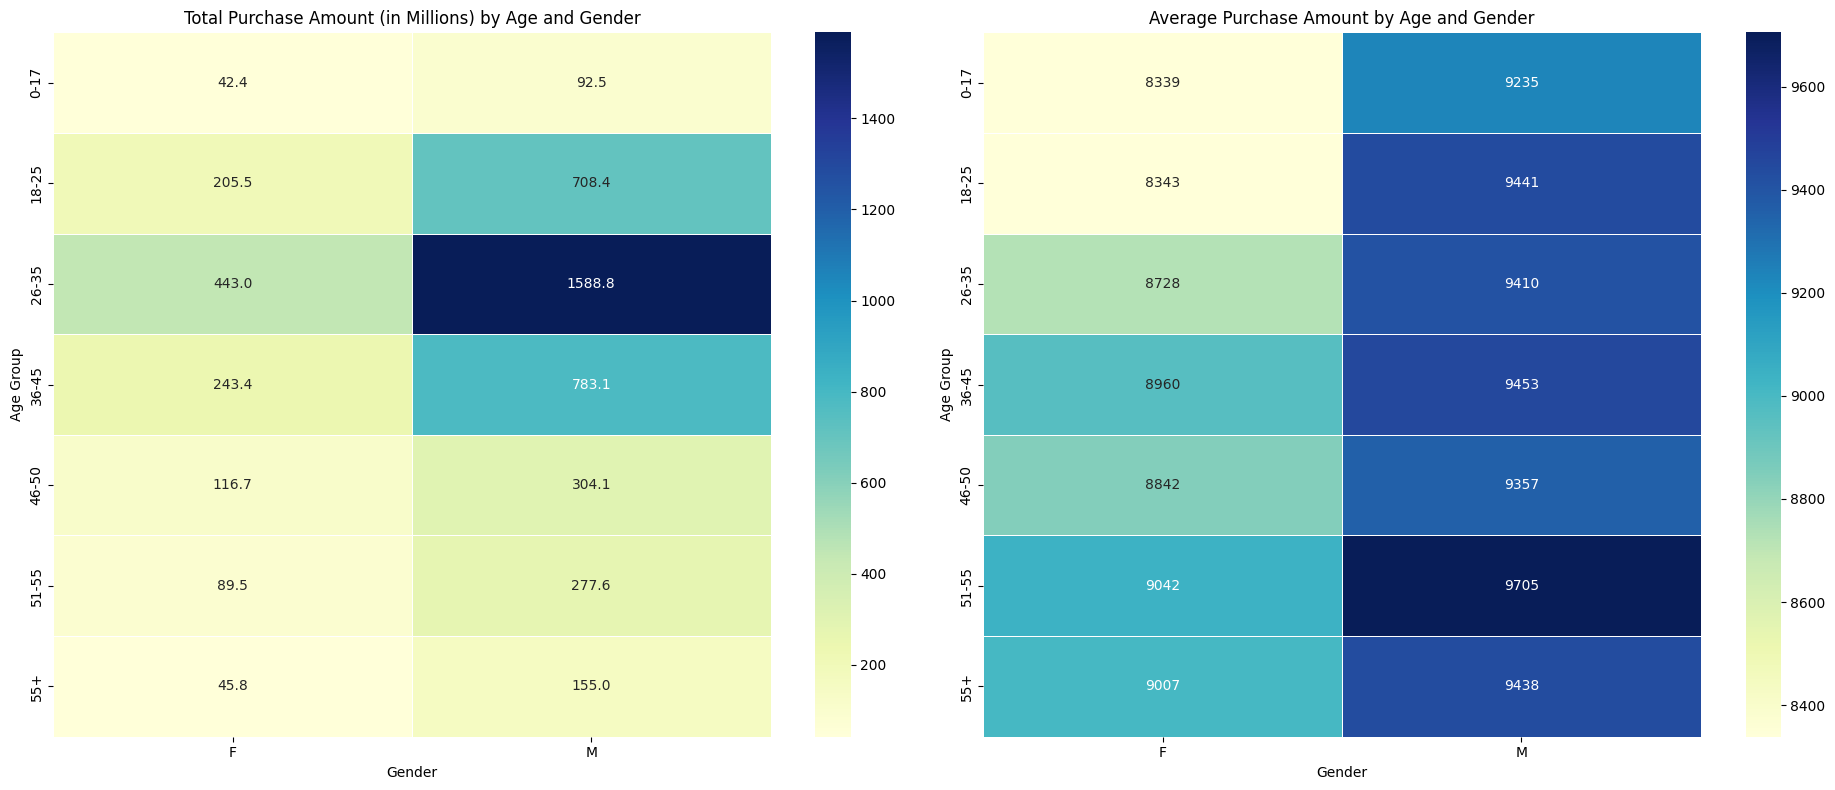

In [ ]:
# Total and Average Purchase Amount by Age and Gender

total_purchase_pivot = df.pivot_table(index='Age', columns='Gender', values='Purchase', aggfunc='sum')
avg_purchase_pivot = df.pivot_table(index='Age', columns='Gender', values='Purchase', aggfunc='mean')

# Convert total purchase to millions
total_purchase_pivot_millions = total_purchase_pivot / 1_000_000

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(19, 8))

# Heatmap for Total Purchase Amount (in Millions)
sns.heatmap(total_purchase_pivot_millions, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set_title('Total Purchase Amount (in Millions) by Age and Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Age Group')

# Heatmap for Average Purchase Amount
sns.heatmap(avg_purchase_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, ax=axes[1])
axes[1].set_title('Average Purchase Amount by Age and Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Age Group')

plt.tight_layout()
plt.show()

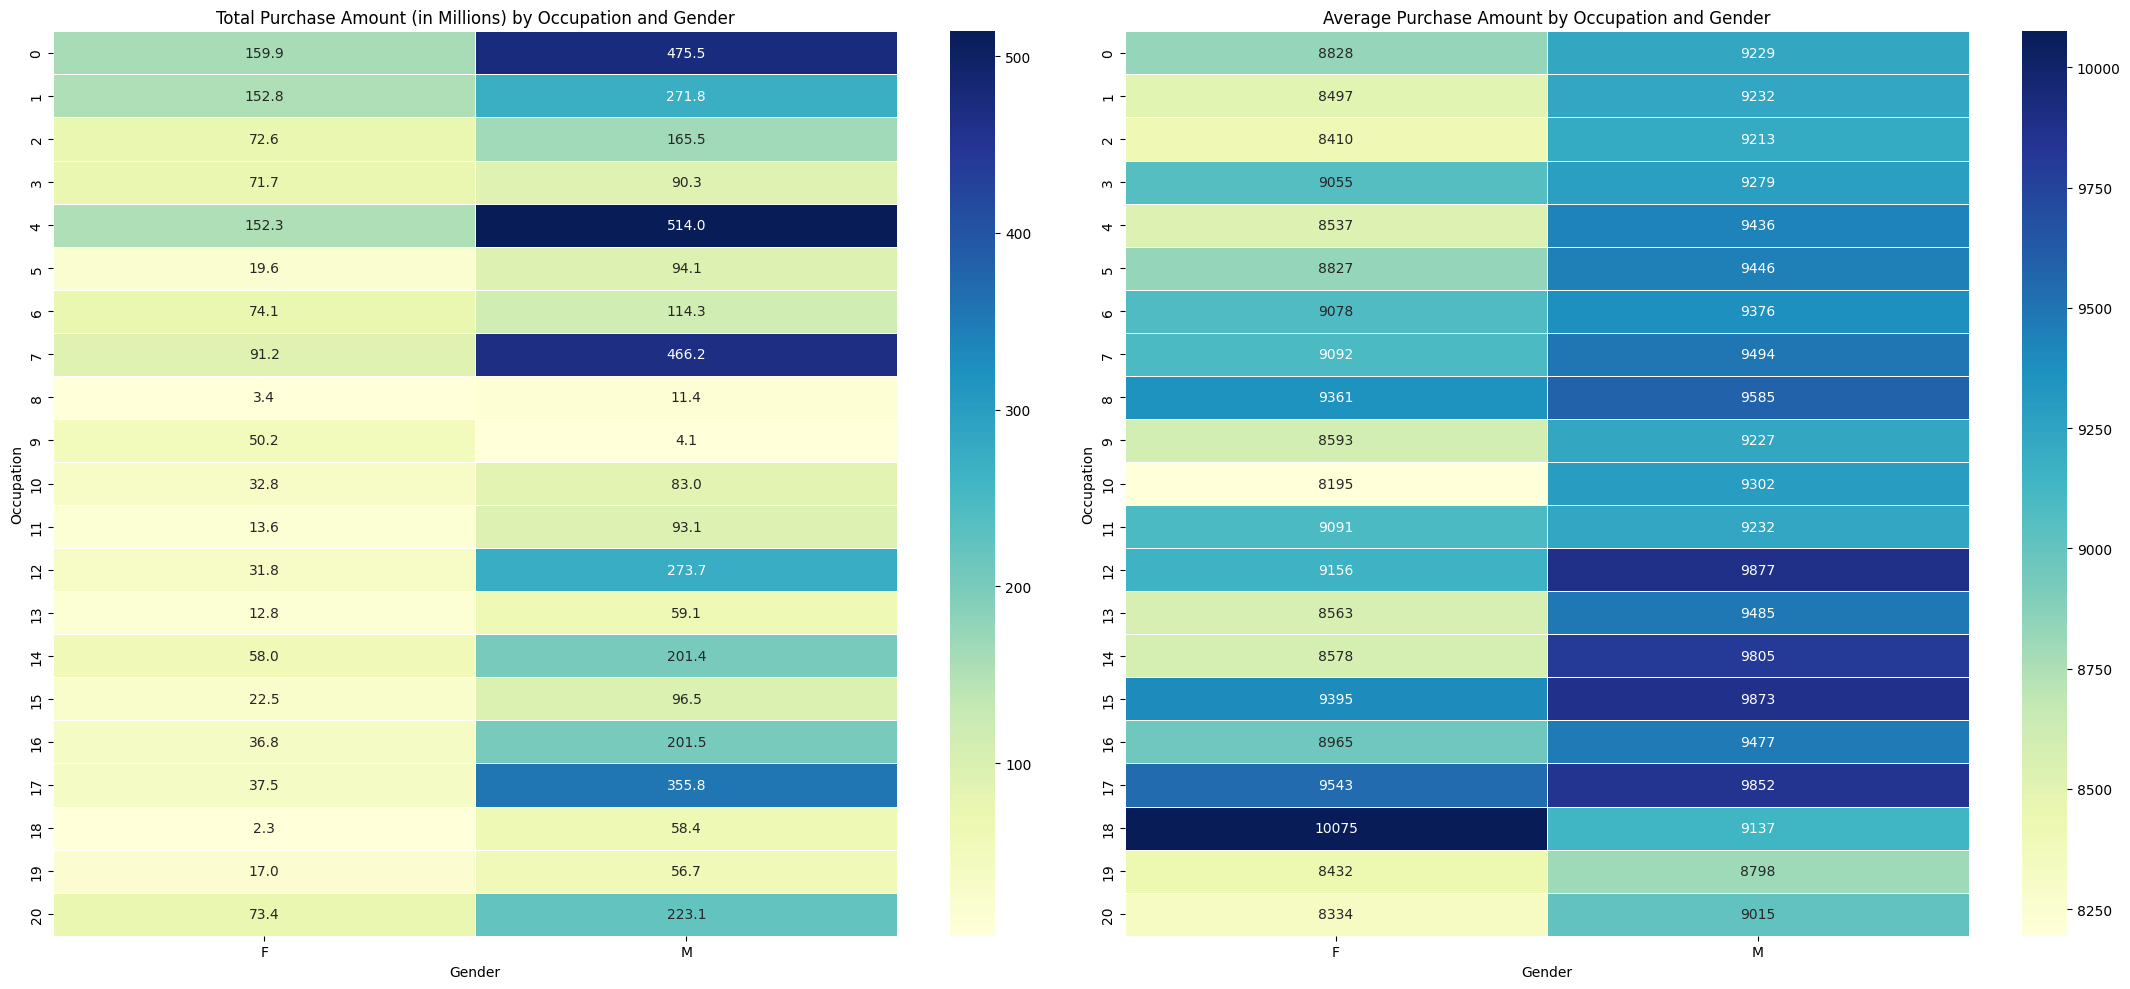

In [ ]:
# Occupation
total_purchase_occupation_pivot = df.pivot_table(index='Occupation', columns='Gender', values='Purchase', aggfunc='sum')
avg_purchase_occupation_pivot = df.pivot_table(index='Occupation', columns='Gender', values='Purchase', aggfunc='mean')

# Convert total purchase to millions
total_purchase_occupation_pivot_millions = total_purchase_occupation_pivot / 1_000_000

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 10))

# Heatmap for Total Purchase Amount (in Millions) by Occupation and Gender
sns.heatmap(total_purchase_occupation_pivot_millions, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set_title('Total Purchase Amount (in Millions) by Occupation and Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Occupation')

# Heatmap for Average Purchase Amount by Occupation and Gender
sns.heatmap(avg_purchase_occupation_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, ax=axes[1])
axes[1].set_title('Average Purchase Amount by Occupation and Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Occupation')

plt.tight_layout()
plt.show()

### Findings from 'Total and Average Purchase Amount by Occupation and Gender' Heatmaps:

**Total Purchase Amount (in Millions):**
*   **Male Majority in Total Purchases:** Across all occupations, male customers consistently show a significantly higher total purchase amount compared to female customers. This reinforces the general trend of male customers contributing more to overall revenue.
*   **Highest Contributing Occupations:** Occupations 4, 0, and 7 appear to be the highest contributors to total sales for both genders, with males in these occupations having substantial total purchases.
*   **Lowest Contributing Occupations:** Some occupations have considerably lower total purchase amounts, especially for female customers.

**Average Purchase Amount:**
*   **Higher Average for Males:** Male customers tend to have a higher average purchase amount across most occupations. This indicates that individual transactions by male customers are generally of higher value.
*   **Relatively Consistent Averages:** While there are variations, the average purchase amounts across different occupations are relatively consistent for both genders, suggesting that occupation might not dramatically alter individual spending habits but rather the volume of purchases.
*   **Occupation 19 and 17:** These occupations show some of the highest average purchases for males, while occupation 15 shows a notably high average for females.

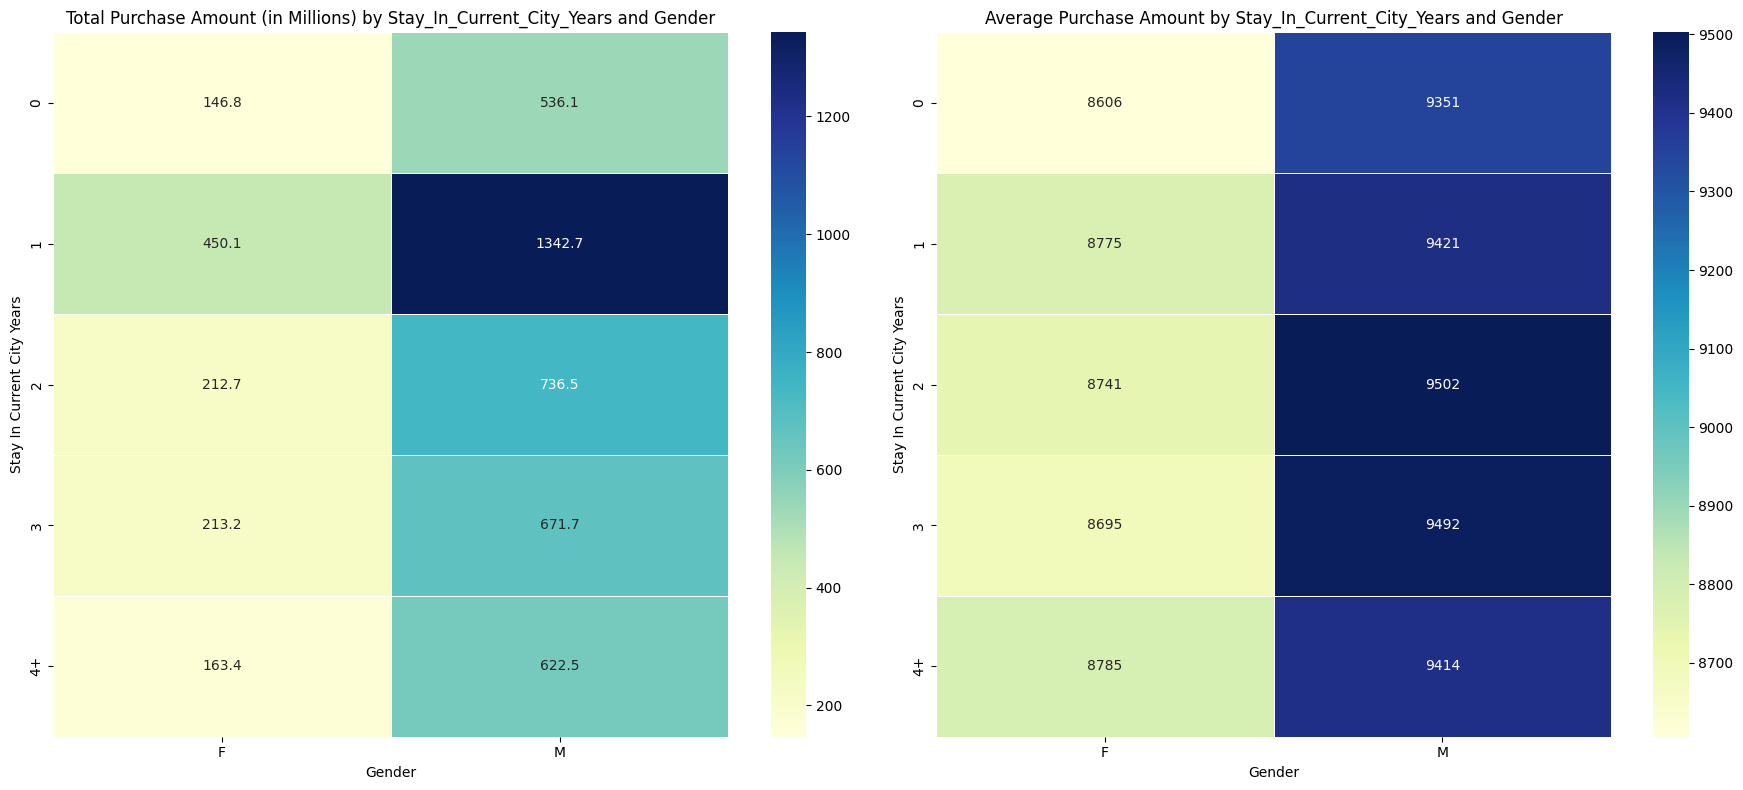

In [ ]:
# Stay_In_Current_City_Years
total_purchase_stay_pivot = df.pivot_table(index='Stay_In_Current_City_Years', columns='Gender', values='Purchase', aggfunc='sum')
avg_purchase_stay_pivot = df.pivot_table(index='Stay_In_Current_City_Years', columns='Gender', values='Purchase', aggfunc='mean')

# Convert total purchase to millions
total_purchase_stay_pivot_millions = total_purchase_stay_pivot / 1_000_000

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Heatmap for Total Purchase Amount (in Millions) by Stay_In_Current_City_Years and Gender
sns.heatmap(total_purchase_stay_pivot_millions, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set_title('Total Purchase Amount (in Millions) by Stay_In_Current_City_Years and Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Stay In Current City Years')

# Heatmap for Average Purchase Amount by Stay_In_Current_City_Years and Gender
sns.heatmap(avg_purchase_stay_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, ax=axes[1])
axes[1].set_title('Average Purchase Amount by Stay_In_Current_City_Years and Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Stay In Current City Years')

plt.tight_layout()
plt.show()

### Findings from 'Total and Average Purchase Amount by Stay_In_Current_City_Years and Gender' Heatmaps:

**Total Purchase Amount (in Millions):**
*   **Male Majority:** Consistent with other variables, male customers show a significantly higher total purchase amount across all 'Stay_In_Current_City_Years' categories.
*   **'1 Year' and '2 Years' as High Contributors:** Customers who have stayed for '1 year' and '2 years' in the current city contribute the most to total purchases for both genders, with males in these categories showing the highest figures.
*   **'4+ Years' also Significant:** The '4+ years' category also shows a substantial contribution, indicating a loyal customer base with considerable spending.

**Average Purchase Amount:**
*   **Higher Average for Males:** On average, male customers tend to have higher purchase amounts regardless of how long they've stayed in the city.
*   **Relatively Consistent Averages:** The average purchase amounts are quite consistent across the different 'Stay_In_Current_City_Years' categories for both genders, suggesting that the duration of stay doesn't heavily influence the average value of a single purchase.

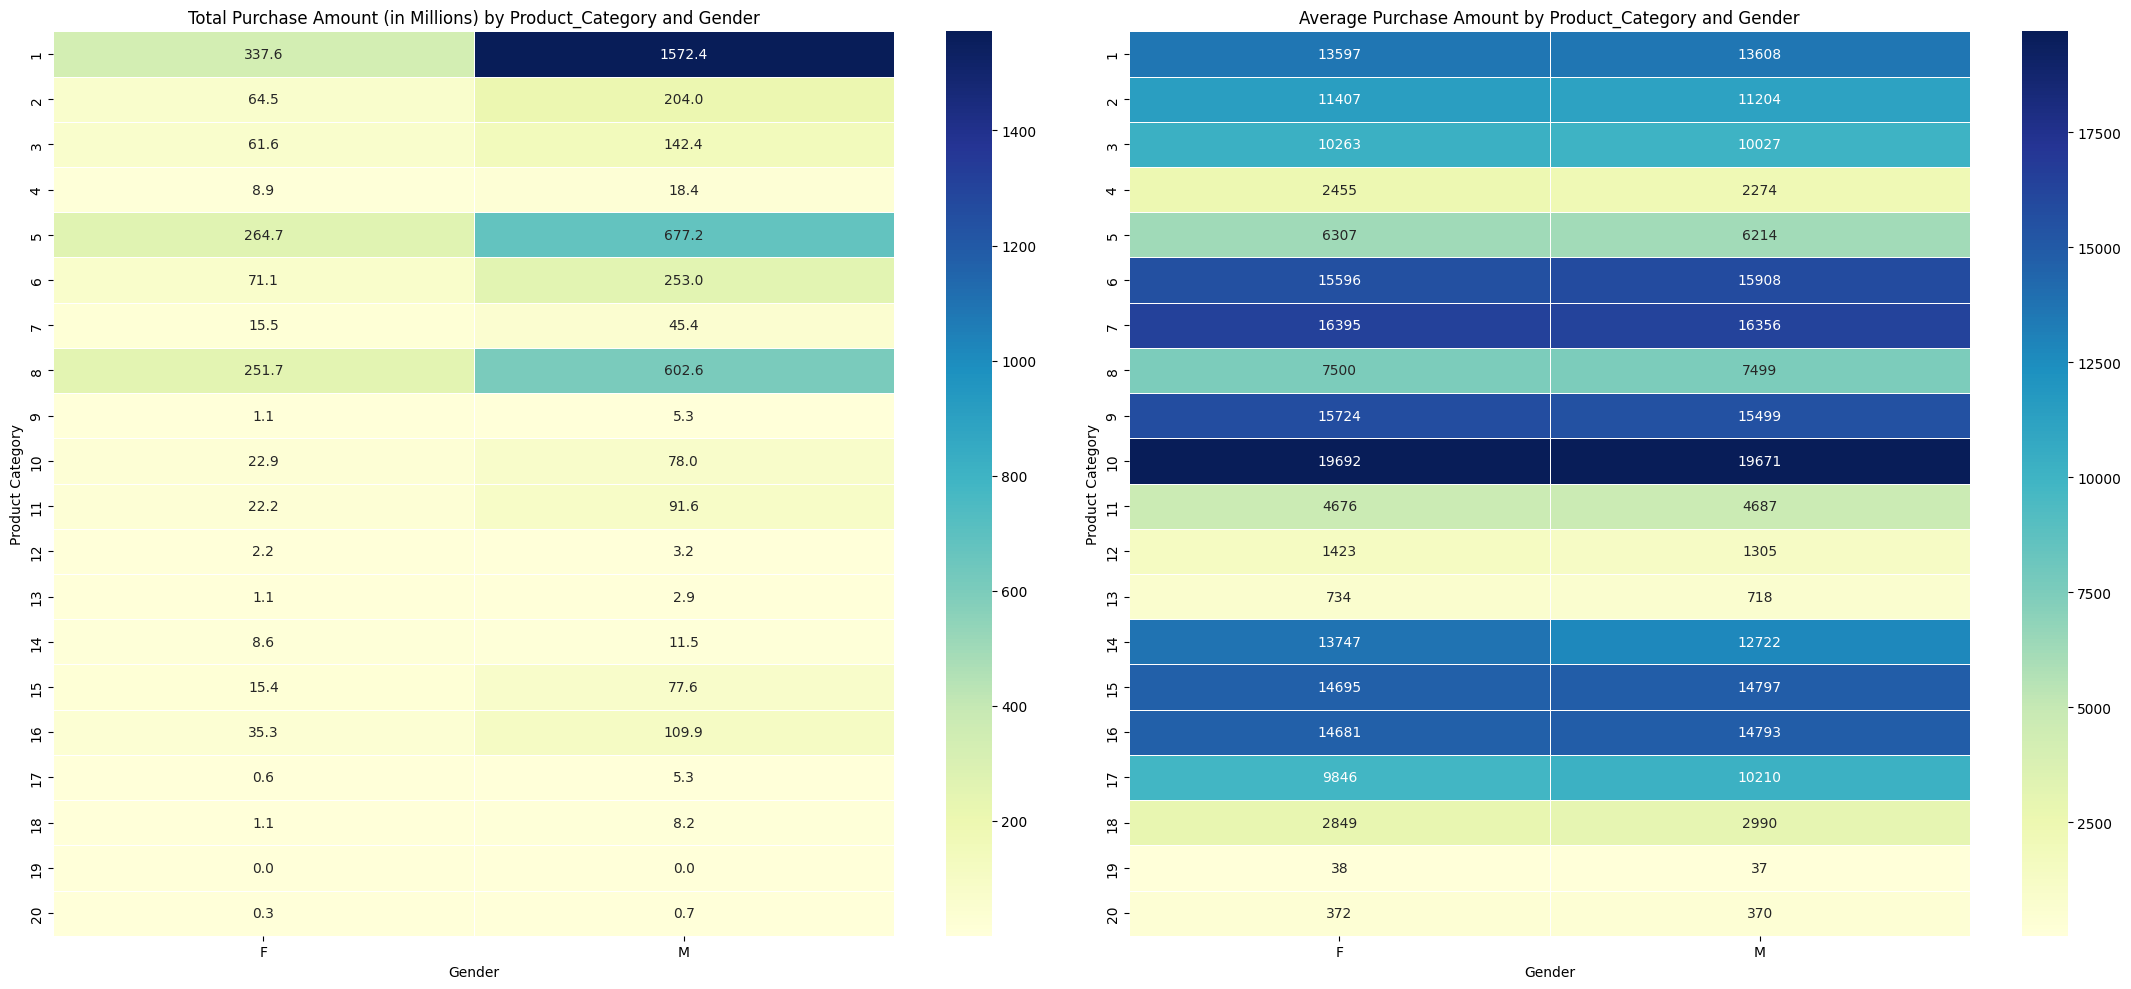

In [ ]:
# Product_Category
total_purchase_product_pivot = df.pivot_table(index='Product_Category', columns='Gender', values='Purchase', aggfunc='sum')
avg_purchase_product_pivot = df.pivot_table(index='Product_Category', columns='Gender', values='Purchase', aggfunc='mean')

# Convert total purchase to millions
total_purchase_product_pivot_millions = total_purchase_product_pivot / 1_000_000

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 10))

# Heatmap for Total Purchase Amount (in Millions) by Product_Category and Gender
sns.heatmap(total_purchase_product_pivot_millions, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set_title('Total Purchase Amount (in Millions) by Product_Category and Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Product Category')

# Heatmap for Average Purchase Amount by Product_Category and Gender
sns.heatmap(avg_purchase_product_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, ax=axes[1])
axes[1].set_title('Average Purchase Amount by Product_Category and Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Product Category')

plt.tight_layout()
plt.show()

### Findings from 'Total and Average Purchase Amount by Product_Category and Gender' Heatmaps:

**Total Purchase Amount (in Millions):**
*   **Male Majority:** For nearly all product categories, male customers account for a significantly larger portion of the total purchase amount. This is a consistent pattern across the dataset.
*   **High-Volume Product Categories:** Product categories 1, 5, and 8 stand out as having the highest total purchase amounts for both genders, indicating these are extremely popular and revenue-generating categories.
*   **Low-Volume Product Categories:** Categories like 19, 20, 10, 17, and 14 show lower total purchase amounts, particularly for female customers.

**Average Purchase Amount:**
*   **Higher Average for Males:** Male customers generally exhibit a higher average purchase amount across various product categories.
*   **Categories with High Average Purchases:** Product categories 10, 6, 16, and 15 show relatively high average purchase amounts for both genders, suggesting that items in these categories might be more expensive on average.
*   **Categories with Lower Average Purchases:** Categories like 3, 12, and 13 tend to have lower average purchase amounts, indicating these might contain less expensive items or be purchased in smaller quantities per transaction.

## Confidence Interval Analysis

In [ ]:
from scipy import stats

def calculate_confidence_interval(data, confidence=0.95):
    """
    Calculates the confidence interval for a given dataset.
    data: Series or array-like of numerical data.
    confidence: The confidence level (e.g., 0.95 for 95% confidence).
    Returns: lower bound, upper bound of the confidence interval.
    """
    n = len(data)
    if n == 0:
        return np.nan, np.nan
    mean = np.mean(data)
    std_err = stats.sem(data) # Standard error of the mean
    h = std_err * stats.t.ppf((1 + confidence) / 2., n-1)
    return mean - h, mean + h

# Separate purchase data by Gender
male_purchases = df[df['Gender'] == 'M']['Purchase']
female_purchases = df[df['Gender'] == 'F']['Purchase']

# Calculate average purchases
mean_male_purchase = male_purchases.mean()
mean_female_purchase = female_purchases.mean()

print(f"Average Male Purchase: {mean_male_purchase:.2f}")
print(f"Average Female Purchase: {mean_female_purchase:.2f}")

# Calculate 95% Confidence Intervals for Gender
ci_male_lower, ci_male_upper = calculate_confidence_interval(male_purchases)
ci_female_lower, ci_female_upper = calculate_confidence_interval(female_purchases)

print(f"\n95% Confidence Interval for Male Purchase: ({ci_male_lower:.2f}, {ci_male_upper:.2f})")
print(f"95% Confidence Interval for Female Purchase: ({ci_female_lower:.2f}, {ci_female_upper:.2f})")


Average Male Purchase: 9437.53
Average Female Purchase: 8734.57

95% Confidence Interval for Male Purchase: (9422.02, 9453.03)
95% Confidence Interval for Female Purchase: (8709.21, 8759.92)


### Inference: Male vs Female Purchase

*   **Average Spend:** The average purchase amount for male customers is significantly higher than that for female customers.
    *   Average Male Purchase: `9437.53`
    *   Average Female Purchase: `8734.57`

*   **Confidence Intervals (95%):**
    *   95% CI for Male Purchase: `(9422.02, 9453.03)`
    *   95% CI for Female Purchase: `(8709.21, 8759.92)`

*   **Overlap Analysis:** The 95% confidence intervals for male and female purchases do not overlap. This strongly suggests that there is a statistically significant difference in the average purchase amount between male and female customers. The population average for male customers' purchases is likely to be higher than that for female customers.

### Walmart's Leverage:

Given the non-overlapping confidence intervals and significantly higher average spend by male customers:

*   **Targeted Marketing:** Walmart could tailor marketing campaigns to focus on product categories and promotions that appeal more to male customers, aiming to capitalize on their higher average spend.
*   **Product Assortment:** Analyze product categories frequently purchased by male customers and consider expanding inventory or offering more premium options within those categories.
*   **Female Customer Engagement:** While male customers have a higher average, understanding why female customers spend less (e.g., different product preferences, shopping frequency) could open opportunities to increase their average transaction value through specific promotions or personalized recommendations.

### Confidence Interval Analysis: Married vs Unmarried

In [ ]:
# Separate purchase data by Marital Status
unmarried_purchases = df[df['Marital_Status'] == 0]['Purchase']
married_purchases = df[df['Marital_Status'] == 1]['Purchase']

# Calculate average purchases
mean_unmarried_purchase = unmarried_purchases.mean()
mean_married_purchase = married_purchases.mean()

print(f"Average Unmarried Purchase: {mean_unmarried_purchase:.2f}")
print(f"Average Married Purchase: {mean_married_purchase:.2f}")

# Calculate 95% Confidence Intervals for Marital Status
ci_unmarried_lower, ci_unmarried_upper = calculate_confidence_interval(unmarried_purchases)
ci_married_lower, ci_married_upper = calculate_confidence_interval(married_purchases)

print(f"\n95% Confidence Interval for Unmarried Purchase: ({ci_unmarried_lower:.2f}, {ci_unmarried_upper:.2f})")
print(f"95% Confidence Interval for Married Purchase: ({ci_married_lower:.2f}, {ci_married_upper:.2f})")


Average Unmarried Purchase: 9265.91
Average Married Purchase: 9261.17

95% Confidence Interval for Unmarried Purchase: (9248.62, 9283.20)
95% Confidence Interval for Married Purchase: (9240.46, 9281.89)


### Inference: Married vs Unmarried Purchase

*   **Average Spend:** The average purchase amounts for married and unmarried customers appear to be quite similar.
    *   Average Unmarried Purchase: `9265.91`
    *   Average Married Purchase: `9261.17`

*   **Confidence Intervals (95%):**
    *   95% CI for Unmarried Purchase: `(9248.62, 9283.20)`
    *   95% CI for Married Purchase: `(9240.46, 9281.89)`

*   **Overlap Analysis:** The 95% confidence intervals for married and unmarried purchases show significant overlap. For instance, the upper bound of the married CI (9281.89) is within the unmarried CI (9248.62, 9283.20), and the lower bound of the unmarried CI (9248.62) is within the married CI (9240.46, 9281.89). This suggests that there is no statistically significant difference in the average purchase amount based on marital status. Both groups tend to spend similarly per transaction.

### Walmart's Leverage:

Since marital status does not appear to be a primary driver of *average* purchase amount:

*   **Segmentation:** While the average spend per transaction might be similar, the *total* purchase volume (as seen in earlier analysis) might differ due to the number of customers in each group. Walmart can segment by marital status for other factors like product preferences or household needs, rather than solely on average spend per transaction.
*   **Broad Appeal:** Marketing strategies related to average transaction value can be broadly applied across both married and unmarried customer segments without significant differentiation.

### Confidence Interval Analysis: Age Groups

In [ ]:
age_bins = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

print("Average Purchase and 95% Confidence Intervals by Age Group:")
for age_group in age_bins:
    age_purchases = df[df['Age'] == age_group]['Purchase']
    mean_age_purchase = age_purchases.mean()
    ci_age_lower, ci_age_upper = calculate_confidence_interval(age_purchases)
    print(f"\nAge Group: {age_group}")
    print(f"  Average Purchase: {mean_age_purchase:.2f}")
    print(f"  95% Confidence Interval: ({ci_age_lower:.2f}, {ci_age_upper:.2f})")


Average Purchase and 95% Confidence Intervals by Age Group:

Age Group: 0-17
  Average Purchase: 8933.46
  95% Confidence Interval: (8851.94, 9014.99)

Age Group: 18-25
  Average Purchase: 9169.66
  95% Confidence Interval: (9138.41, 9200.92)

Age Group: 26-35
  Average Purchase: 9252.69
  95% Confidence Interval: (9231.73, 9273.65)

Age Group: 36-45
  Average Purchase: 9331.35
  95% Confidence Interval: (9301.67, 9361.03)

Age Group: 46-50
  Average Purchase: 9208.63
  95% Confidence Interval: (9163.08, 9254.17)

Age Group: 51-55
  Average Purchase: 9534.81
  95% Confidence Interval: (9483.99, 9585.63)

Age Group: 55+
  Average Purchase: 9336.28
  95% Confidence Interval: (9269.30, 9403.27)


### Inference: Age Group Purchase

*   **Average Spend and 95% Confidence Intervals:**
    *   Age Group `0-17`: Average Purchase: `8933.46`, 95% CI: `(8851.94, 9014.99)`
    *   Age Group `18-25`: Average Purchase: `9169.66`, 95% CI: `(9138.41, 9200.92)`
    *   Age Group `26-35`: Average Purchase: `9252.69`, 95% CI: `(9231.73, 9273.65)`
    *   Age Group `36-45`: Average Purchase: `9331.35`, 95% CI: `(9301.67, 9361.03)`
    *   Age Group `46-50`: Average Purchase: `9208.63`, 95% CI: `(9163.08, 9254.17)`
    *   Age Group `51-55`: Average Purchase: `9534.81`, 95% CI: `(9483.99, 9585.63)`
    *   Age Group `55+`: Average Purchase: `9336.28`, 95% CI: `(9269.30, 9403.27)`

*   **Overlap Analysis:**
    *   The confidence interval for **0-17** (`8851.94, 9014.99`) does not overlap with any of the other age groups. This suggests that the youngest age group has a statistically significantly lower average purchase.
    *   The confidence intervals for **18-25**, **26-35**, **36-45**, **46-50**, and **55+** show substantial overlap with each other, indicating that the average purchase amounts among these groups are not statistically significantly different at the 95% confidence level.
    *   The **51-55** age group (`9483.99, 9585.63`) stands out as having a higher average purchase. Its confidence interval overlaps with the upper end of the `36-45` and `55+` groups, but does not overlap with the `0-17`, `18-25`, `26-35`, or `46-50` groups, suggesting a statistically significant higher average spend for this particular age bracket.

*   **Key Observations:**
    *   The `51-55` age group has the highest average purchase, followed closely by `36-45` and `55+`.
    *   The `0-17` age group has the lowest average purchase.
    *   There is a general trend of increasing average purchase with age, peaking in the `51-55` group, and then slightly decreasing or stabilizing for `55+`.
    *   The width of the confidence intervals is relatively narrow for all groups, indicating good precision in our estimates.

### Walmart's Leverage:

*   **Age-Specific Promotions:** Tailor promotions and product recommendations to specific age groups where significant differences in average spend are observed. For example, the `51-55` age group, with its highest average purchases, could be targeted with high-value products or premium offers. The `0-17` age group might benefit from entry-level or value-oriented product promotions.
*   **Store Layout/Product Placement:** Consider arranging product categories that are popular with high-spending age groups (e.g., `51-55`) in easily accessible or prominent areas.
*   **Loyalty Programs:** Develop loyalty programs that reward high-spending age groups or incentivize lower-spending groups to increase their average transaction value. For the `0-17` group, strategies could focus on fostering early loyalty and encouraging family purchases.

### Experimenting with Confidence Levels and Sample Sizes (Central Limit Theorem)

Sample Size: 50, 90% CI of Sample Means: (9386.42, 9461.47)
Sample Size: 500, 90% CI of Sample Means: (9434.78, 9458.41)
Sample Size: 5000, 90% CI of Sample Means: (9433.36, 9440.67)


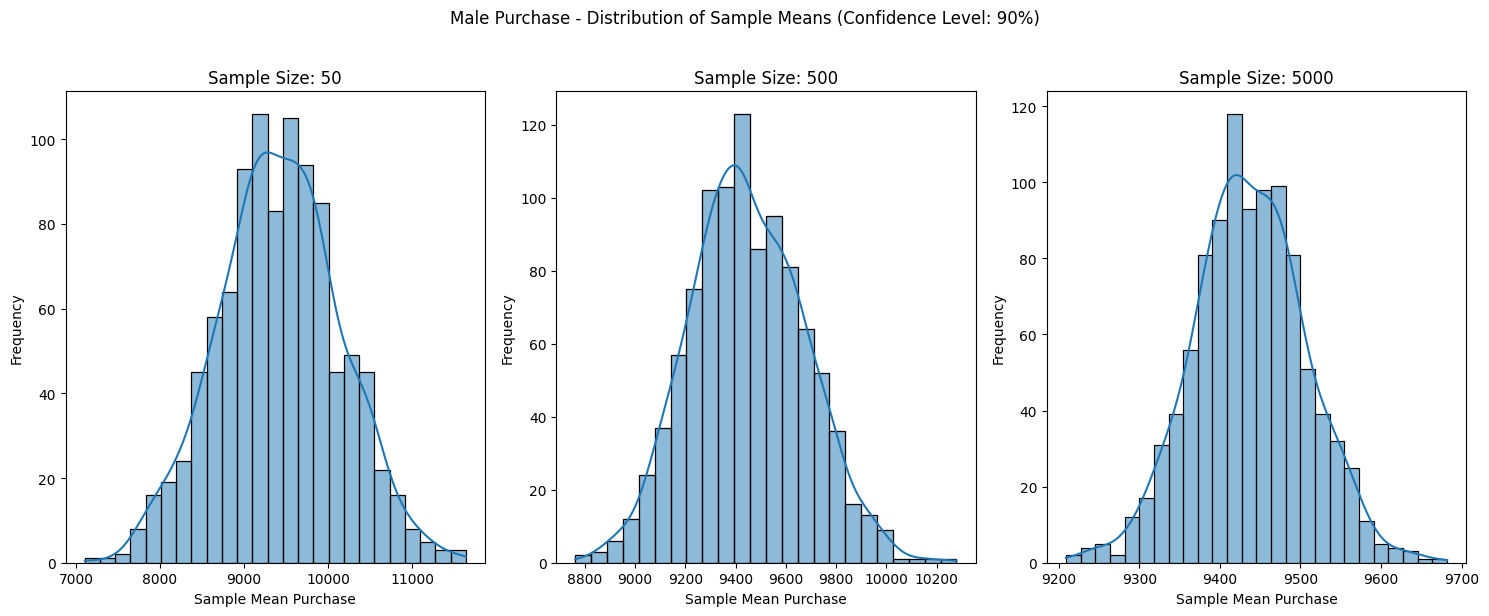

Sample Size: 50, 90% CI of Sample Means: (8736.70, 8806.01)
Sample Size: 500, 90% CI of Sample Means: (8718.97, 8742.29)
Sample Size: 5000, 90% CI of Sample Means: (8729.13, 8736.35)


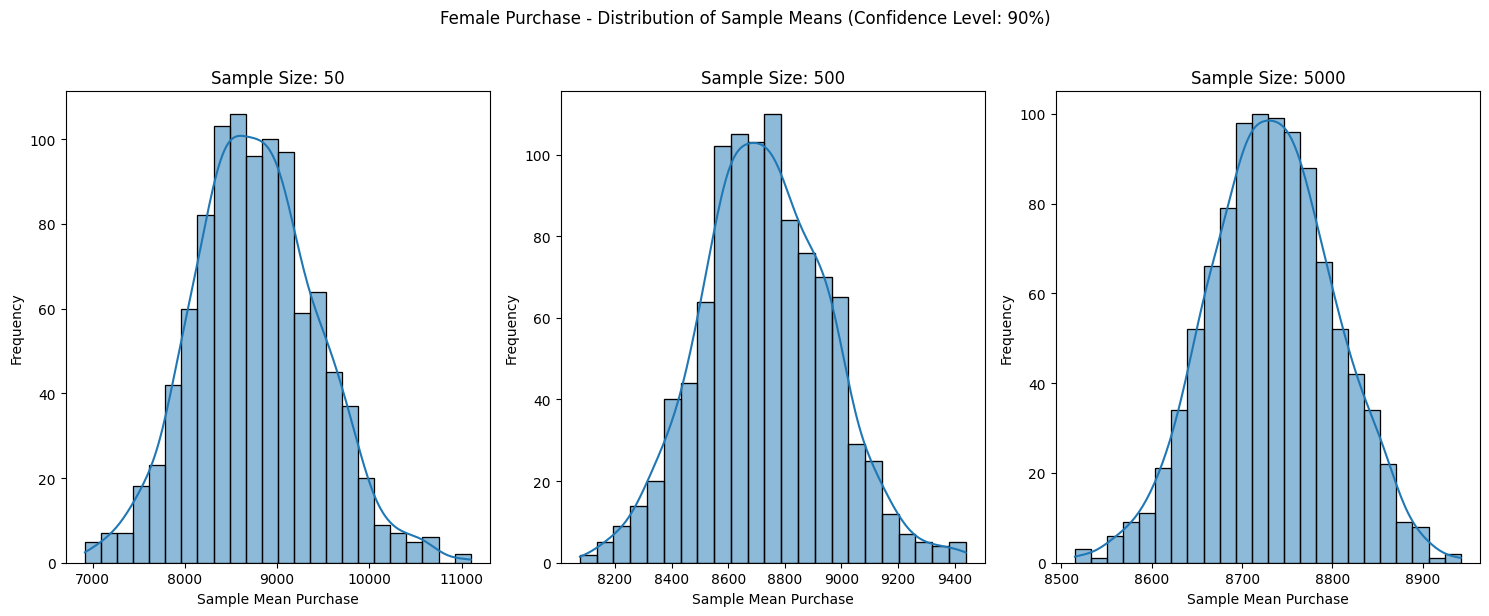

Sample Size: 50, 95% CI of Sample Means: (9413.60, 9504.12)
Sample Size: 500, 95% CI of Sample Means: (9434.87, 9463.44)
Sample Size: 5000, 95% CI of Sample Means: (9431.93, 9440.89)


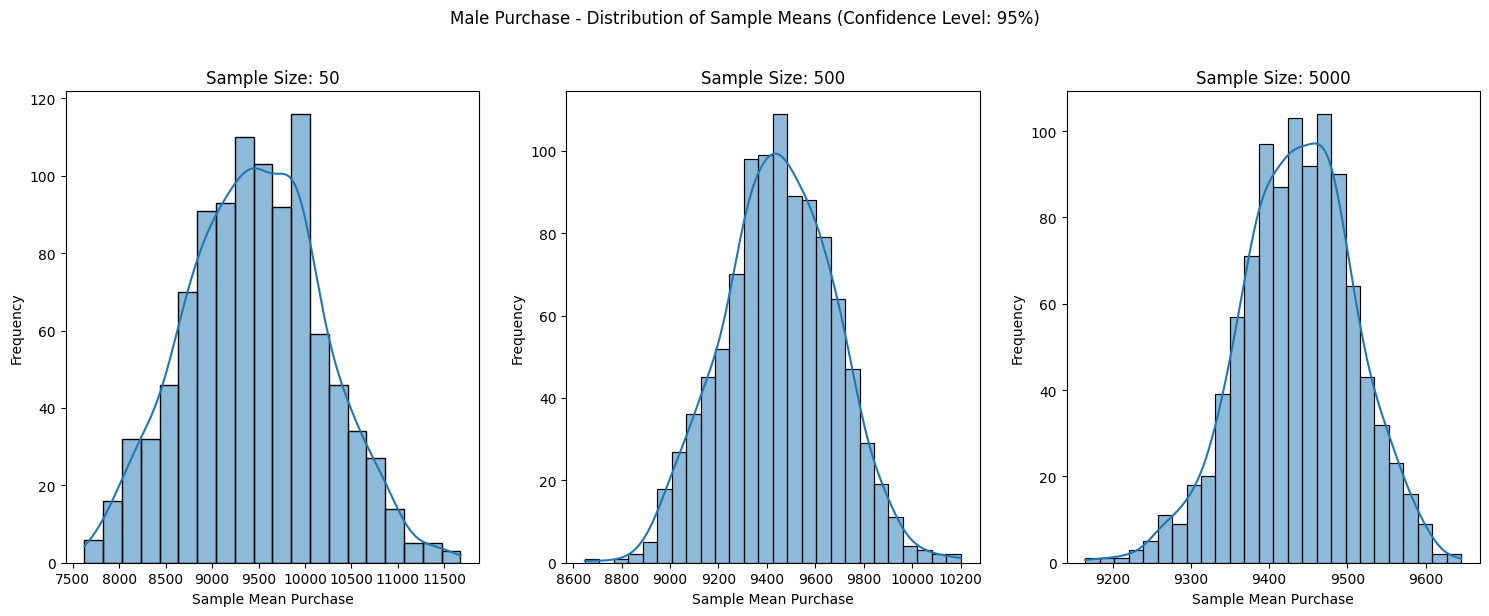

Sample Size: 50, 95% CI of Sample Means: (8704.40, 8790.00)
Sample Size: 500, 95% CI of Sample Means: (8728.05, 8754.35)
Sample Size: 5000, 95% CI of Sample Means: (8726.32, 8734.67)


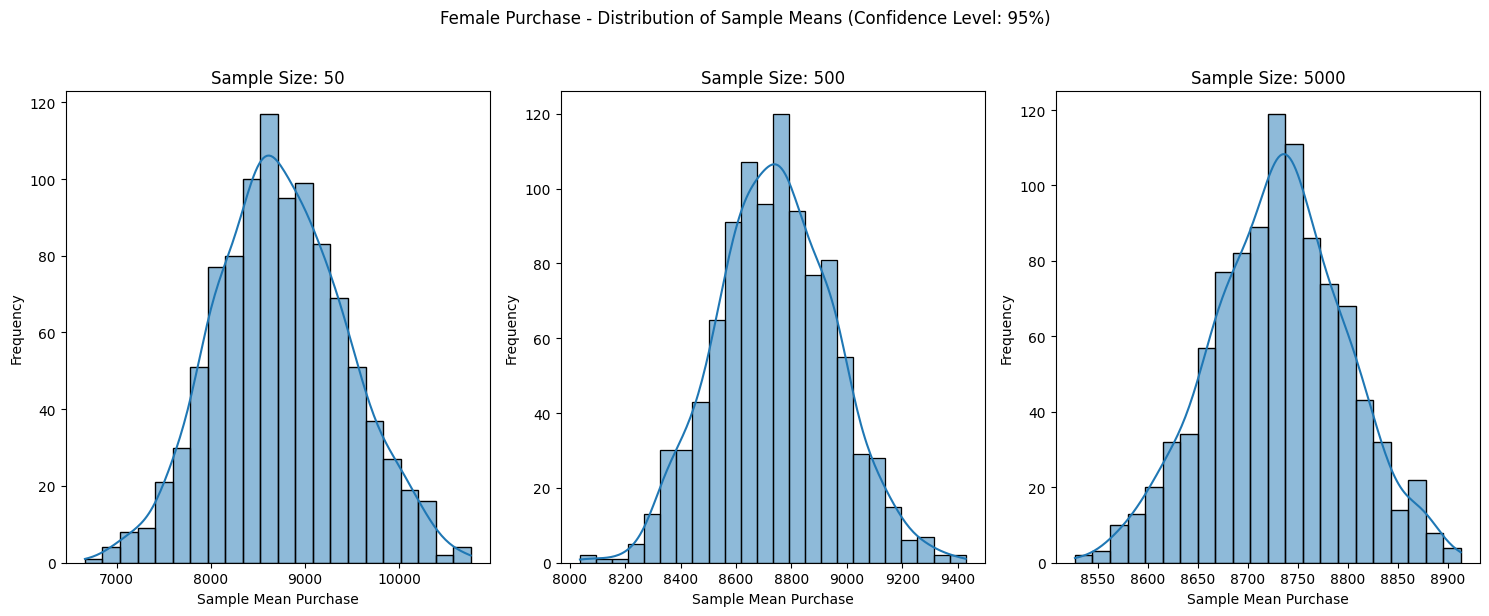

Sample Size: 50, 99% CI of Sample Means: (9392.78, 9510.96)
Sample Size: 500, 99% CI of Sample Means: (9419.97, 9456.50)
Sample Size: 5000, 99% CI of Sample Means: (9430.55, 9442.81)


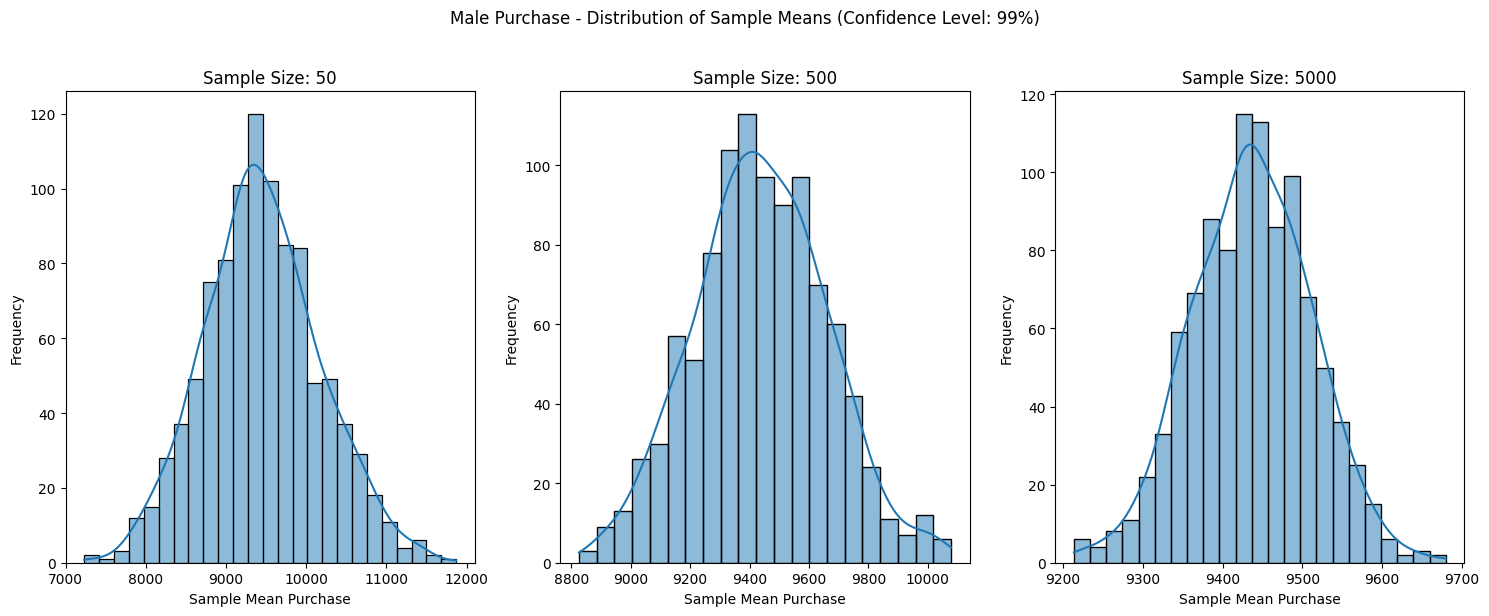

Sample Size: 50, 99% CI of Sample Means: (8652.44, 8760.28)
Sample Size: 500, 99% CI of Sample Means: (8716.27, 8750.70)
Sample Size: 5000, 99% CI of Sample Means: (8728.41, 8739.75)


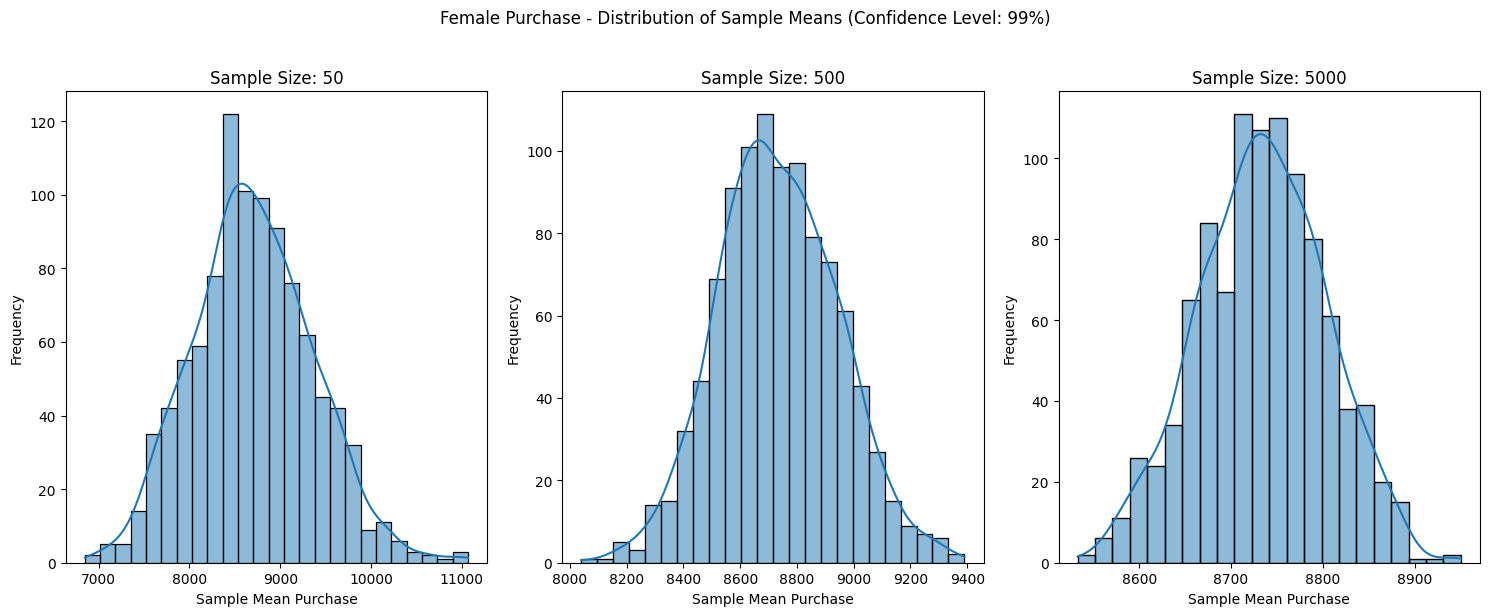

In [ ]:
def plot_mean_distribution(data, sample_sizes, num_samples=1000, confidence_level=0.95, title="Distribution of Sample Means"):
    """
    Plots the distribution of sample means for different sample sizes and calculates CI.
    data: Original dataset.
    sample_sizes: List of sample sizes to experiment with.
    num_samples: Number of samples to draw for each sample size.
    confidence_level: The confidence level for CI calculation.
    """
    plt.figure(figsize=(15, 6))
    all_sample_means = []

    for i, sample_size in enumerate(sample_sizes):
        sample_means = []
        for _ in range(num_samples):
            sample = data.sample(n=sample_size, replace=True)
            sample_means.append(sample.mean())

        all_sample_means.append(sample_means)

        plt.subplot(1, len(sample_sizes), i + 1)
        sns.histplot(sample_means, kde=True)
        plt.title(f'Sample Size: {sample_size}')
        plt.xlabel('Sample Mean Purchase')
        plt.ylabel('Frequency')

        # Calculate CI for this distribution of sample means
        ci_lower, ci_upper = calculate_confidence_interval(sample_means, confidence=confidence_level)
        print(f"Sample Size: {sample_size}, {int(confidence_level*100)}% CI of Sample Means: ({ci_lower:.2f}, {ci_upper:.2f})")

    plt.suptitle(f'{title} (Confidence Level: {int(confidence_level*100)}%)', y=1.02)
    plt.tight_layout()
    plt.show()

# Experiment with male purchases data
sample_sizes_to_test = [50, 500, 5000]
confidence_levels_to_test = [0.90, 0.95, 0.99]

for conf_level in confidence_levels_to_test:
    plot_mean_distribution(male_purchases, sample_sizes_to_test, confidence_level=conf_level, title='Male Purchase - Distribution of Sample Means')
    plot_mean_distribution(female_purchases, sample_sizes_to_test, confidence_level=conf_level, title='Female Purchase - Distribution of Sample Means')


### Observations on Sample Size and Confidence Level:

*   **Effect of Sample Size:** As the sample size increases (e.g., from 50 to 5000), the distribution of sample means becomes narrower and more concentrated around the true population mean. This is a direct illustration of the Central Limit Theorem: larger sample sizes lead to more precise estimates of the population mean, resulting in tighter confidence intervals.

*   **Effect of Confidence Level:**
    *   **Lower Confidence (e.g., 90%):** Results in narrower confidence intervals, meaning we are more precise in our estimate but have a lower certainty that the true population mean lies within this range.
    *   **Higher Confidence (e.g., 99%):** Results in wider confidence intervals, meaning we are more certain that the true population mean is within the range, but the estimate is less precise.

*   **Business Implications:** The choice of confidence level and sample size depends on the acceptable risk and desired precision for business decisions. For critical decisions, a higher confidence level (e.g., 99%) might be preferred, even if it results in a wider interval. For initial insights or less critical decisions, a 90% or 95% confidence level might suffice.

### Findings:

1.  **Average Purchase Amount:** Our analysis, specifically the confidence interval for average purchase, shows that male customers have a statistically significantly higher average purchase amount (`9437.53`) compared to female customers (`8734.57`). The 95% confidence intervals for male purchases `(9422.02, 9453.03)` and female purchases `(8709.21, 8759.92)` do not overlap, strongly indicating a true difference in population averages.

2.  **Total Purchase Volume:** While the business problem assumes 50 million male and 50 million female customers, our *dataset* indicates a significantly higher number of male customers across various categories (Age, City Category, Stay in Current City Years, Marital Status, Product Category, Occupation). This, combined with a higher average spend, leads to a substantially higher *total* purchase amount by male customers in the observed data.

3.  **Consistency Across Categories:** This trend of males having higher average purchases and total purchase volume is consistent even when breaking down by other factors such as City Category, Marital Status, Occupation, and Product Category.

**Conclusion to the Question:** Based on the dataset analysis, **women do not spend more than men on Black Friday; in fact, male customers exhibit a higher average purchase amount and contribute more to the total purchase volume.**

### Recommendations for Walmart:

1.  **Optimize for Male Customer Spending:**
    *   **Targeted Marketing:** Develop marketing campaigns and promotions specifically appealing to male customers, focusing on products and deals that historically drive their higher average purchases. Leverage advertising channels and messages that resonate with this demographic.
    *   **Product Assortment:** Analyze product categories and brands that are most popular among male customers and expand inventory, offer exclusive deals, or enhance the shopping experience for these products.

2.  **Enhance Female Customer Engagement:**
    *   **Understand Female Preferences:** Conduct further research (e.g., surveys, focus groups) to understand product preferences, shopping motivations, and pain points for female customers. Are there specific product categories where female spending could be boosted?
    *   **Personalized Recommendations:** Implement personalization engines to recommend products to female customers based on their browsing history and purchase patterns, aiming to increase their average transaction value.
    *   **Promotional Strategies:** Explore promotions or bundles that are attractive to female shoppers, potentially focusing on value, convenience, or product bundles that encourage higher basket sizes.

3.  **Gender-Neutral Enhancements:**
    *   Continue to improve the overall shopping experience (online and in-store) for all customers, as a positive experience can encourage higher spending and loyalty regardless of gender.
    *   Monitor these trends over time, as customer behavior can evolve, and adjust strategies accordingly.